# Single Detector Analysis: UID 89

In [1]:
import os, glob, sqlite3, datetime
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from Dpipe.load_ptod import DpipeTODCuts
from matplotlib.ticker import FuncFormatter, MultipleLocator

DB    = '/data/users/class/dpipe_db/w1_templates_20260203.db'
DTOD  = '/data/users/class/mapmaking_in/dtod/w1_band/56lp'      #demod version
ADCSV = '/home/carolcyy/moby/Dpipe/data/ArrayData/w1_band/current/array_data.csv'
CACHE = '/tmp/2f_cut_study_meta.npz'
NDET  = 616

# calibrated per-segment 2f metric used by the cuts = |amplitude * scaling_factor|
# the 4 ModTemplate cut files:
F2F = ['ModTemplateLowMedian_0.01045', 'ModTemplateHighVariance_4e-05',
       'ModTemplateAmplitudeOutlier_1.5', 'ModTemplateQualityAmpConditionCut_Q0.95_A0.005']
SHORT = ['LowMedian', 'HighVariance', 'AmpOutlier', 'QualAmpCond']
CCOL  = ['C0', 'C1', 'C2', 'C3']
MINMED, MINBASE, QTHR = 0.01045, 0.0125, 0.95     # LowMedian thr / pre-filter amp / quality

In [2]:
# --- per-detector mean 2f amplitude (one DB pass, cached) ---
if os.path.exists(CACHE):
    z = np.load(CACHE); MEAN2f, MQUAL, NSEG = z['mean2f'], z['mqual'], z['nseg']
    tmin, tmax, nseg_tot, nspan_db = float(z['tmin']), float(z['tmax']), int(z['nseg_tot']), int(z['nspan'])
else:
    con = sqlite3.connect(f'file:{DB}?mode=ro', uri=True)
    MEAN2f = np.full(NDET, np.nan); MQUAL = np.full(NDET, np.nan); NSEG = np.zeros(NDET, int)
    for u, m, q, n in con.execute("""SELECT det_uid, AVG(ABS(amplitude*scaling_factor)),
                                     AVG(quality), COUNT(*) FROM templates GROUP BY det_uid"""):
        if u < NDET: MEAN2f[u], MQUAL[u], NSEG[u] = m, q, n
    tmin, tmax = con.execute("SELECT MIN(timestamp),MAX(timestamp) FROM segments").fetchone()
    nseg_tot = con.execute("SELECT COUNT(*) FROM segments").fetchone()[0]
    nspan_db = con.execute("SELECT COUNT(*) FROM spans").fetchone()[0]
    con.close()
    np.savez(CACHE, mean2f=MEAN2f, mqual=MQUAL, nseg=NSEG,
             tmin=tmin, tmax=tmax, nseg_tot=nseg_tot, nspan=nspan_db)

ad   = pd.read_csv(ADCSV).set_index('det_uid')
ROW  = ad['row'].reindex(range(NDET)).values
LIVE = NSEG > 0.5 * np.median(NSEG[NSEG > 0])       # detectors with substantial data

d0, d1 = (datetime.datetime.utcfromtimestamp(t).date() for t in (tmin, tmax))
print(f"detectors in DB : {np.isfinite(MEAN2f).sum()}   (of {NDET};  live={LIVE.sum()})")
print(f"spans (DB)      : {nspan_db}        spans (dtod cut files): "
      f"{len(glob.glob(f'{DTOD}/2024-*')+glob.glob(f'{DTOD}/2025-*'))}")
print(f"segments total  : {nseg_tot}")
print(f"date range      : {d0} -> {d1}")
print(f"mean 2f (live)  : median={np.nanmedian(MEAN2f[LIVE]):.4f}  "
      f"min={np.nanmin(MEAN2f[LIVE]):.4f}  max={np.nanmax(MEAN2f[LIVE]):.4f}")

detectors in DB : 345   (of 616;  live=332)
spans (DB)      : 290        spans (dtod cut files): 286
segments total  : 86606
date range      : 2024-07-01 -> 2025-08-29
mean 2f (live)  : median=0.0164  min=0.0005  max=0.0247


In [8]:
# load in template table from database
con = sqlite3.connect(f'file:{DB}?mode=ro', uri=True)

pf = pd.read_sql_query(
    "SELECT det_uid AS uid, "
    "segment_id, "
    "ABS(amplitude*scaling_factor) AS a, "
    "quality "
    "FROM templates",
    con
)

con.close()

In [9]:
# load in segment table from database
con = sqlite3.connect(f'file:{DB}?mode=ro', uri=True)

df_spans = pd.read_sql_query(
    "SELECT *"
    "FROM segments",
    con
)

con.close()

In [20]:
# load in span table from database
con = sqlite3.connect(f'file:{DB}?mode=ro', uri=True)

spans = pd.read_sql_query(
    "SELECT *"
    "FROM spans",
    con
)

con.close()
spans.sort_values(by='path', ascending=True, inplace=True)
spans

,id,path,processed_time,boresight,elevation
13,27,2024-07-01-21-30-00_71,2026-02-03T15:44:30.233853,45,None
19,35,2024-07-02-21-30-00_86,2026-02-03T15:56:55.811663,30,None
20,36,2024-07-03-21-40-00_85,2026-02-03T15:57:27.797898,45,None
18,34,2024-07-04-21-40-00_85,2026-02-03T15:55:36.990202,-45,None
17,33,2024-07-05-22-10-00_82,2026-02-03T15:54:41.924257,-30,None
...,...,...,...,...,...
285,301,2025-08-23-22-50-00_75,2026-02-05T21:58:37.637661,-15,None
286,302,2025-08-25-22-00-00_80,2026-02-05T22:06:36.854644,15,None
287,303,2025-08-26-23-00-00_74,2026-02-05T22:14:06.715359,30,None
289,305,2025-08-27-23-50-00_69,2026-02-05T22:16:08.360623,45,None


In [21]:
span_info = df_spans.merge(spans, left_on='span_id', right_on='id', how='inner')
span_info = span_info.drop(columns=['subdivision_index', 'mod_freq', 'modulator_type', 'processed_time', 'elevation', 'id_y'])
span_info.rename(columns={"id_x": "segment_id"}, inplace=True)
span_info

,segment_id,span_id,timestamp,site_pwv,path,boresight
0,277,3,1.721462e+09,2.01,2024-07-20-07-50-00_23,45
1,278,3,1.721462e+09,2.01,2024-07-20-07-50-00_23,45
2,279,3,1.721463e+09,2.01,2024-07-20-07-50-00_23,45
3,280,3,1.721463e+09,2.01,2024-07-20-07-50-00_23,45
4,281,3,1.721463e+09,1.99,2024-07-20-07-50-00_23,45
...,...,...,...,...,...,...
82421,86602,305,1.756379e+09,0.56,2025-08-27-23-50-00_69,45
82422,86603,305,1.756379e+09,0.56,2025-08-27-23-50-00_69,45
82423,86604,305,1.756380e+09,0.56,2025-08-27-23-50-00_69,45
82424,86605,305,1.756380e+09,0.56,2025-08-27-23-50-00_69,45


In [22]:
span_info.to_csv("span_info.csv", index=False)

In [23]:
span_info = pd.read_csv("span_info.csv")
span_info

,segment_id,span_id,timestamp,site_pwv,path,boresight
0,277,3,1.721462e+09,2.01,2024-07-20-07-50-00_23,45
1,278,3,1.721462e+09,2.01,2024-07-20-07-50-00_23,45
2,279,3,1.721463e+09,2.01,2024-07-20-07-50-00_23,45
3,280,3,1.721463e+09,2.01,2024-07-20-07-50-00_23,45
4,281,3,1.721463e+09,1.99,2024-07-20-07-50-00_23,45
...,...,...,...,...,...,...
82421,86602,305,1.756379e+09,0.56,2025-08-27-23-50-00_69,45
82422,86603,305,1.756379e+09,0.56,2025-08-27-23-50-00_69,45
82423,86604,305,1.756380e+09,0.56,2025-08-27-23-50-00_69,45
82424,86605,305,1.756380e+09,0.56,2025-08-27-23-50-00_69,45


In [24]:
from datetime import datetime
span_info['datetime'] = pd.to_datetime(span_info["timestamp"], unit="s", utc=True).dt.round("1s")
span_info["time"] = span_info["datetime"].dt.time
span_info

,segment_id,span_id,timestamp,site_pwv,path,boresight,datetime,time
0,277,3,1.721462e+09,2.01,2024-07-20-07-50-00_23,45,2024-07-20 07:57:30+00:00,07:57:30
1,278,3,1.721462e+09,2.01,2024-07-20-07-50-00_23,45,2024-07-20 07:59:59+00:00,07:59:59
2,279,3,1.721463e+09,2.01,2024-07-20-07-50-00_23,45,2024-07-20 08:02:29+00:00,08:02:29
3,280,3,1.721463e+09,2.01,2024-07-20-07-50-00_23,45,2024-07-20 08:04:59+00:00,08:04:59
4,281,3,1.721463e+09,1.99,2024-07-20-07-50-00_23,45,2024-07-20 08:07:29+00:00,08:07:29
...,...,...,...,...,...,...,...,...
82421,86602,305,1.756379e+09,0.56,2025-08-27-23-50-00_69,45,2025-08-28 11:07:29+00:00,11:07:29
82422,86603,305,1.756379e+09,0.56,2025-08-27-23-50-00_69,45,2025-08-28 11:09:59+00:00,11:09:59
82423,86604,305,1.756380e+09,0.56,2025-08-27-23-50-00_69,45,2025-08-28 11:12:29+00:00,11:12:29
82424,86605,305,1.756380e+09,0.56,2025-08-27-23-50-00_69,45,2025-08-28 11:14:59+00:00,11:14:59


In [25]:
full_pf = pd.merge(pf, span_info, left_on='segment_id', right_on='segment_id')#.drop(columns=['timestamp'])

In [26]:
NSPAN = full_pf['span_id'].max()
good_pf = full_pf[full_pf["quality"] >= 0.5]
#g = full_pf.groupby(['uid', 'span_id'])
g = good_pf.groupby(['uid', 'span_id'])

uids = np.sort(full_pf['uid'].unique())
span_ids = np.sort(full_pf['span_id'].unique())

# get mean, variance, number of datapkg's for each detector, span pair
pmean = np.full(NDET, np.nan); pmed = np.full((NDET, NSPAN+1), np.nan)
pvar = np.full((NDET, NSPAN+1), np.nan); pn = np.zeros((NDET, NSPAN+1))
for (uid, span_id), sub in g:
    vals = sub["a"].values
    pmed[uid, span_id] = np.median(vals)
    pvar[uid, span_id] = np.var(vals)
    pn[uid, span_id]   = len(vals)

In [98]:
span_order = np.argsort(pmed[89])[::-1]
sorted_spans = span_order
sorted_values = pmed[89][span_order]

top15_span_ids = np.argsort(np.nan_to_num(pmed[89], nan=-np.inf))[::-1][:15]
bottom15_span_ids = np.argsort(np.nan_to_num(pmed[89], nan=np.inf))[:15]
median15_span_ids = np.argsort(np.abs(pmed[89] - np.nanmedian(pmed[89])))[:15]

In [15]:
print(pmed[89][median15_span_ids])


[0.01204405 0.01205735 0.01204253 0.01209019 0.01200021 0.0119317
 0.01218192 0.01189763 0.01187384 0.01187151 0.01187109 0.01223544
 0.01224179 0.01226315 0.01182787]


In [99]:
det_89 = full_pf[full_pf['uid']==89].copy()
det_89

,uid,segment_id,a,quality,span_id,timestamp,site_pwv,path,boresight,datetime,time
48,89,277,0.009569,0.999965,3,1.721462e+09,2.01,2024-07-20-07-50-00_23,45,2024-07-20 07:57:30+00:00,07:57:30
389,89,278,0.009587,0.999996,3,1.721462e+09,2.01,2024-07-20-07-50-00_23,45,2024-07-20 07:59:59+00:00,07:59:59
729,89,279,0.009589,0.999997,3,1.721463e+09,2.01,2024-07-20-07-50-00_23,45,2024-07-20 08:02:29+00:00,08:02:29
1069,89,280,0.009579,0.999997,3,1.721463e+09,2.01,2024-07-20-07-50-00_23,45,2024-07-20 08:04:59+00:00,08:04:59
1408,89,281,0.009559,0.999996,3,1.721463e+09,1.99,2024-07-20-07-50-00_23,45,2024-07-20 08:07:29+00:00,08:07:29
...,...,...,...,...,...,...,...,...,...,...,...
26825103,89,86602,0.008637,0.999992,305,1.756379e+09,0.56,2025-08-27-23-50-00_69,45,2025-08-28 11:07:29+00:00,11:07:29
26825432,89,86603,0.008606,0.999993,305,1.756379e+09,0.56,2025-08-27-23-50-00_69,45,2025-08-28 11:09:59+00:00,11:09:59
26825761,89,86604,0.008602,0.999992,305,1.756380e+09,0.56,2025-08-27-23-50-00_69,45,2025-08-28 11:12:29+00:00,11:12:29
26826090,89,86605,0.008643,0.999994,305,1.756380e+09,0.56,2025-08-27-23-50-00_69,45,2025-08-28 11:14:59+00:00,11:14:59


In [63]:
det_47 = full_pf[full_pf['uid']==47].copy()
span_3 = det_47[det_47['span_id']==241].copy()
span_3.sort_values(by="datetime")

,uid,segment_id,a,quality,span_id,timestamp,path,datetime,time
19853593,47,65508,0.003479,0.952288,241,1.747192e+09,2025-05-13-21-40-00_83,2025-05-14 03:05:00+00:00,03:05:00
19853929,47,65509,0.005137,0.981230,241,1.747192e+09,2025-05-13-21-40-00_83,2025-05-14 03:07:30+00:00,03:07:30
19854266,47,65510,0.004569,0.977902,241,1.747192e+09,2025-05-13-21-40-00_83,2025-05-14 03:09:59+00:00,03:09:59
19854598,47,65511,0.004393,0.986531,241,1.747192e+09,2025-05-13-21-40-00_83,2025-05-14 03:12:29+00:00,03:12:29
19854929,47,65512,0.003064,0.976649,241,1.747192e+09,2025-05-13-21-40-00_83,2025-05-14 03:14:59+00:00,03:14:59
19855264,47,65513,0.002775,0.947539,241,1.747193e+09,2025-05-13-21-40-00_83,2025-05-14 03:17:29+00:00,03:17:29
19855599,47,65514,0.001830,0.858756,241,1.747193e+09,2025-05-13-21-40-00_83,2025-05-14 03:19:59+00:00,03:19:59
19855930,47,65515,0.001354,0.789967,241,1.747193e+09,2025-05-13-21-40-00_83,2025-05-14 03:22:29+00:00,03:22:29
19856260,47,65516,0.000429,0.494970,241,1.747193e+09,2025-05-13-21-40-00_83,2025-05-14 03:24:59+00:00,03:24:59
19856590,47,65517,0.000680,0.611377,241,1.747193e+09,2025-05-13-21-40-00_83,2025-05-14 03:27:30+00:00,03:27:30


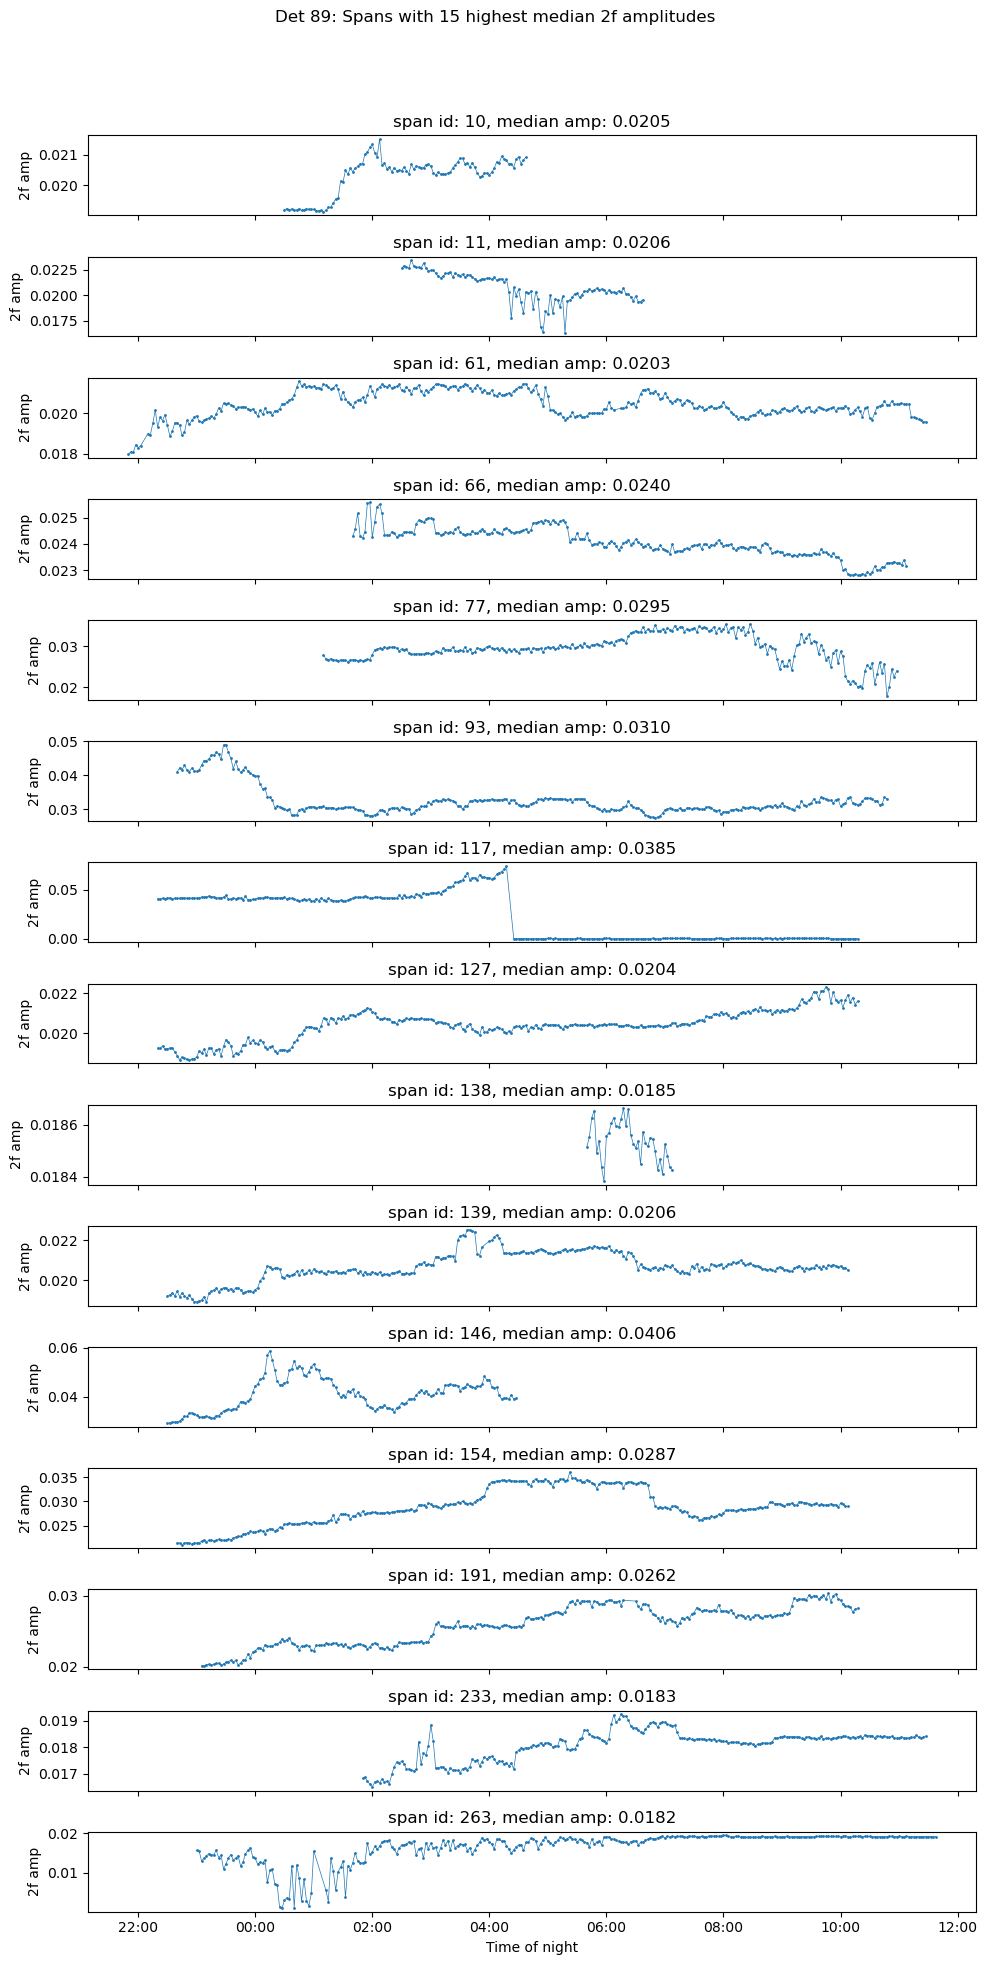

In [100]:
# Convert Unix timestamp to datetime
det_89["datetime"] = pd.to_datetime(det_89["timestamp"], unit="s").dt.round("1s")

# Seconds since the observing day starts
dt = det_89["datetime"]

# Define observing day (noon to noon)
det_89['obs_time'] = (det_89["datetime"] - pd.Timedelta(hours=12)).dt.date

# Calculate seconds since midnight
det_89["time_of_night"] = (
    dt.dt.hour * 3600
    + dt.dt.minute * 60
    + dt.dt.second
    + dt.dt.microsecond / 1e6
)

# Shift so times wrap continuously through midnight
# Times before noon (00:00-11:59) get 24 hours added to appear after evening times
det_89["time_of_night_shifted"] = det_89["time_of_night"].copy()
det_89.loc[det_89["time_of_night"] < 12*3600, "time_of_night_shifted"] += 24*3600
top15_data = det_89[det_89["span_id"].isin(top15_span_ids)]

# Plot
#plt.figure(figsize=(10, 4))
fig, ax = plt.subplots(15,1, sharex=True, figsize=(10,20))

#plt.plot(det_89["time_of_night_shifted"], det_89["a"], ".-")

i = 0
for span_id, group in top15_data.groupby("span_id"):
    ax[i].plot(
        group["time_of_night_shifted"],
        group["a"],
        ".-",
        linewidth=0.5,
        markersize=2,
        label=str(span_id)
    )
    ax[i].set_ylabel("2f amp")
    ax[i].set_title(f"span id: {span_id}, median amp: {pmed[89][span_id]:.4f}")
    i +=1

# Format x-axis to display clock time (handles 24+ hours)
def fmt_time(x, pos):
    total_hours = x / 3600
    h = int(total_hours % 24)  # Wrap hours back to 0-23
    m = int((x % 3600) // 60)
    return f"{h:02d}:{m:02d}"

ax = plt.gca()
ax.xaxis.set_major_locator(MultipleLocator(2*3600))  # Every 2 hours
ax.xaxis.set_major_formatter(FuncFormatter(fmt_time))

plt.xlabel("Time of night")
fig.suptitle("Det 89: Spans with 15 highest median 2f amplitudes", y=0.98)
fig.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

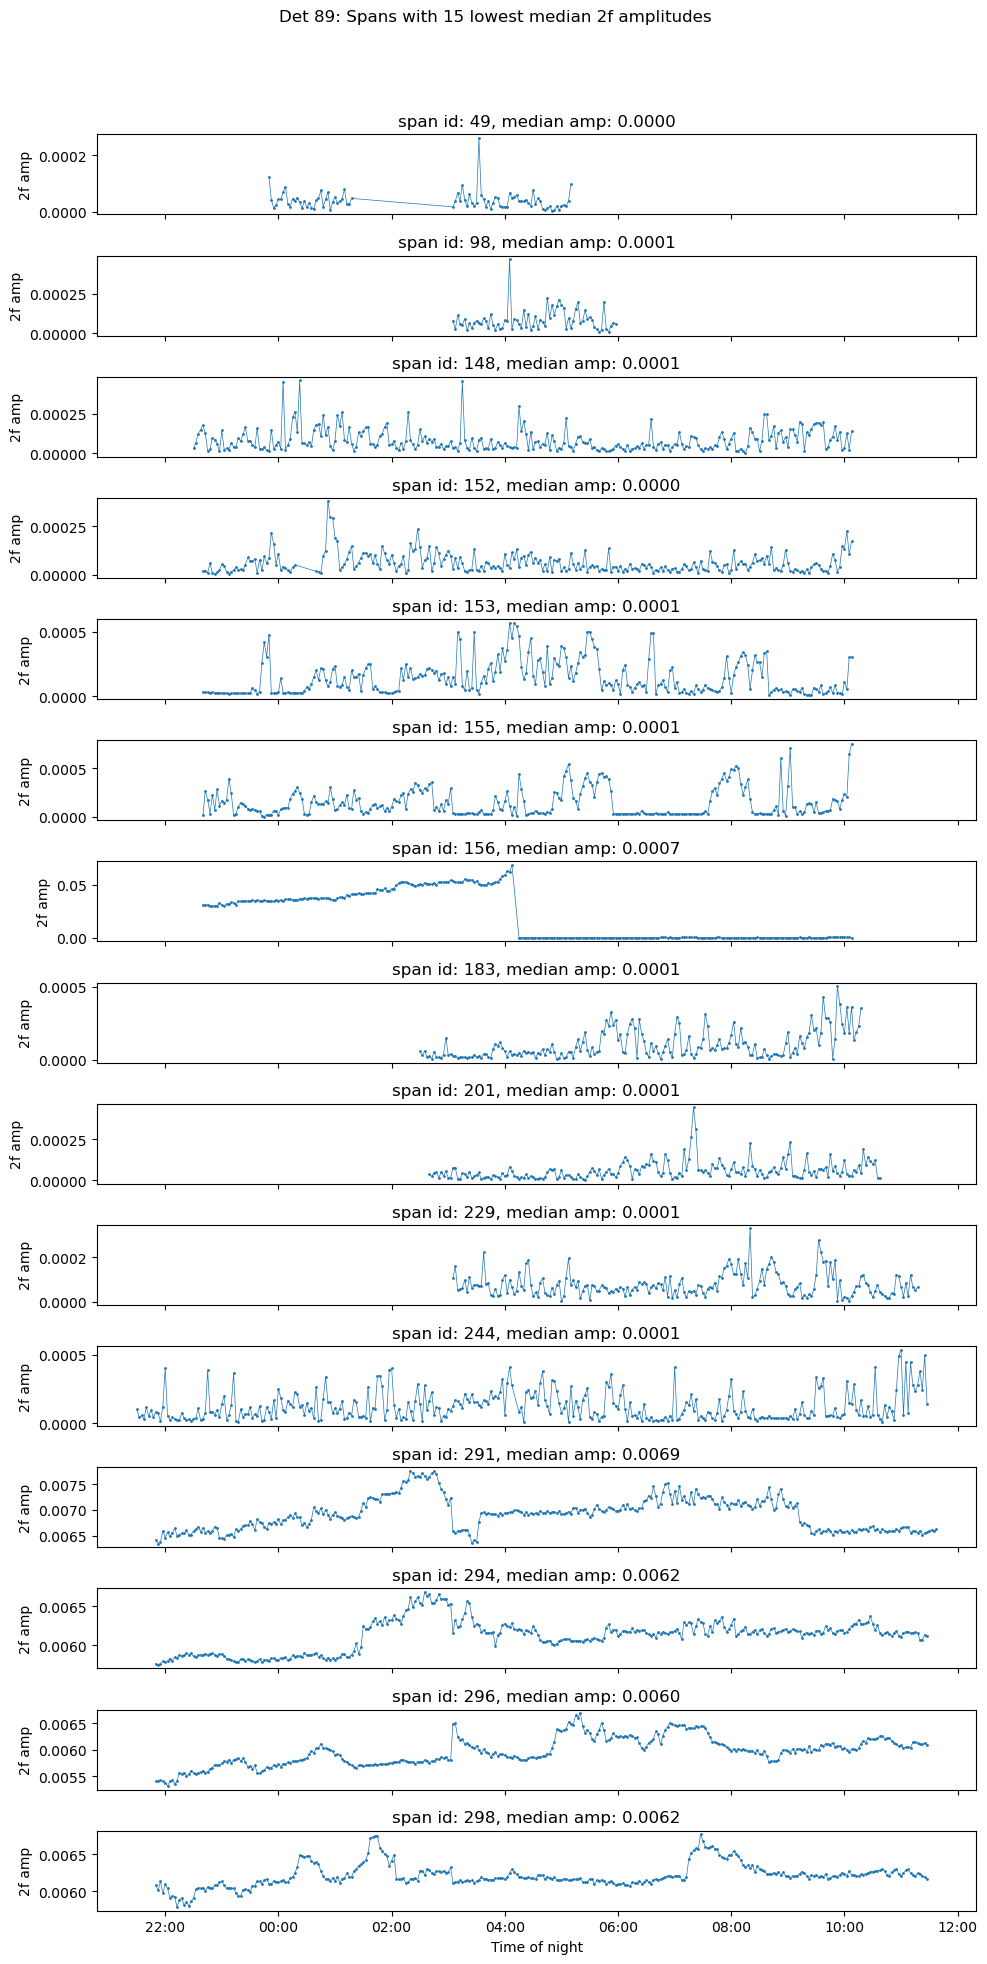

In [101]:
bottom_15_data = det_89[det_89["span_id"].isin(bottom15_span_ids)]

# Plot
#plt.figure(figsize=(10, 4))
fig, ax = plt.subplots(15,1, sharex=True, figsize=(10,20))

#plt.plot(det_89["time_of_night_shifted"], det_89["a"], ".-")

i = 0
for span_id, group in bottom_15_data.groupby("span_id"):
    ax[i].plot(
        group["time_of_night_shifted"],
        group["a"],
        ".-",
        linewidth=0.5,
        markersize=2,
        label=str(span_id)
    )
    ax[i].set_ylabel("2f amp")
    ax[i].set_title(f"span id: {span_id}, median amp: {pmed[89][span_id]:.4f}")
    i +=1

# Format x-axis to display clock time (handles 24+ hours)
def fmt_time(x, pos):
    total_hours = x / 3600
    h = int(total_hours % 24)  # Wrap hours back to 0-23
    m = int((x % 3600) // 60)
    return f"{h:02d}:{m:02d}"

ax = plt.gca()
ax.xaxis.set_major_locator(MultipleLocator(2*3600))  # Every 2 hours
ax.xaxis.set_major_formatter(FuncFormatter(fmt_time))

plt.xlabel("Time of night")
fig.suptitle("Det 89: Spans with 15 lowest median 2f amplitudes", y=0.98)
fig.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [110]:
bottom_15_data[bottom_15_data['span_id']==156]

,uid,segment_id,a,quality,span_id,timestamp,site_pwv,path,boresight,datetime,time,obs_time,time_of_night,time_of_night_shifted
11960361,89,41125,0.031226,0.999931,156,1.733006e+09,2.96,2024-11-30-22-40-00_69,-15,2024-11-30 22:40:00,22:40:00,2024-11-30,81600.0,81600.0
11960678,89,41126,0.030512,0.999913,156,1.733007e+09,2.96,2024-11-30-22-40-00_69,-15,2024-11-30 22:42:30,22:42:30,2024-11-30,81750.0,81750.0
11960995,89,41127,0.031257,0.999982,156,1.733007e+09,2.96,2024-11-30-22-40-00_69,-15,2024-11-30 22:45:00,22:45:00,2024-11-30,81900.0,81900.0
11961312,89,41128,0.030133,0.999957,156,1.733007e+09,2.85,2024-11-30-22-40-00_69,-15,2024-11-30 22:47:30,22:47:30,2024-11-30,82050.0,82050.0
11961629,89,41129,0.029698,0.999964,156,1.733007e+09,2.85,2024-11-30-22-40-00_69,-15,2024-11-30 22:50:00,22:50:00,2024-11-30,82200.0,82200.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12046594,89,41396,0.000761,0.999460,156,1.733047e+09,1.50,2024-11-30-22-40-00_69,-15,2024-12-01 09:57:29,09:57:29,2024-11-30,35849.0,122249.0
12046907,89,41397,0.000622,0.997810,156,1.733047e+09,1.50,2024-11-30-22-40-00_69,-15,2024-12-01 09:59:59,09:59:59,2024-11-30,35999.0,122399.0
12047220,89,41398,0.000449,0.997868,156,1.733047e+09,1.50,2024-11-30-22-40-00_69,-15,2024-12-01 10:02:29,10:02:29,2024-11-30,36149.0,122549.0
12047533,89,41399,0.000443,0.999322,156,1.733047e+09,1.50,2024-11-30-22-40-00_69,-15,2024-12-01 10:04:59,10:04:59,2024-11-30,36299.0,122699.0


In [31]:
median15_data = det_89[det_89["span_id"].isin(median15_span_ids)]
median15_data

,uid,segment_id,a,quality,span_id,timestamp,site_pwv,path,boresight,datetime,time,obs_time,time_of_night,time_of_night_shifted
57994,89,456,0.011445,0.999921,5,1.721708e+09,4.11,2024-07-23-04-10-00_25,-30,2024-07-23 04:12:29,04:12:29,2024-07-22,15149.0,101549.0
58326,89,457,0.011934,0.999950,5,1.721708e+09,4.11,2024-07-23-04-10-00_25,-30,2024-07-23 04:14:59,04:14:59,2024-07-22,15299.0,101699.0
58660,89,458,0.012007,0.999975,5,1.721708e+09,4.12,2024-07-23-04-10-00_25,-30,2024-07-23 04:17:29,04:17:29,2024-07-22,15449.0,101849.0
58993,89,459,0.012026,0.999988,5,1.721708e+09,4.12,2024-07-23-04-10-00_25,-30,2024-07-23 04:19:59,04:19:59,2024-07-22,15599.0,101999.0
59325,89,460,0.011699,0.999974,5,1.721709e+09,4.12,2024-07-23-04-10-00_25,-30,2024-07-23 04:22:29,04:22:29,2024-07-22,15749.0,102149.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26649025,89,86078,0.012230,0.999991,303,1.756293e+09,0.89,2025-08-26-23-00-00_74,30,2025-08-27 11:07:30,11:07:30,2025-08-26,40050.0,126450.0
26649352,89,86079,0.012320,0.999993,303,1.756293e+09,0.89,2025-08-26-23-00-00_74,30,2025-08-27 11:10:00,11:10:00,2025-08-26,40200.0,126600.0
26649679,89,86080,0.012283,0.999993,303,1.756293e+09,0.89,2025-08-26-23-00-00_74,30,2025-08-27 11:12:30,11:12:30,2025-08-26,40350.0,126750.0
26650006,89,86081,0.012466,0.999997,303,1.756293e+09,0.89,2025-08-26-23-00-00_74,30,2025-08-27 11:15:00,11:15:00,2025-08-26,40500.0,126900.0


In [103]:
print(bottom_15_data['path'].unique())

['2024-08-20-23-50-00_33' '2024-10-06-22-10-00_75'
 '2024-11-18-22-30-00_70' '2024-11-22-22-40-00_69'
 '2024-11-27-22-40-00_69' '2024-11-29-22-40-00_69'
 '2024-11-30-22-40-00_69' '2025-01-04-02-30-00_47'
 '2025-02-03-02-40-00_48' '2025-05-01-21-40-00_82'
 '2025-05-16-21-30-00_84' '2025-07-28-21-50-00_83'
 '2025-08-11-21-50-00_82' '2025-08-13-21-50-00_82'
 '2025-08-14-21-50-00_82']


In [57]:
top15var_span_ids = np.argsort(np.nan_to_num(pvar[89], nan=-np.inf))[::-1][:15]
bottom15var_span_ids = np.argsort(np.nan_to_num(pvar[89], nan=np.inf))[:15]
median15var_span_ids = np.argsort(np.abs(pvar[89] - np.nanmedian(pvar[89])))[:15]

top15var_data = det_89[det_89["span_id"].isin(top15var_span_ids)]
median15var_data = det_89[det_89["span_id"].isin(median15var_span_ids)]
bottom15var_data = det_89[det_89["span_id"].isin(bottom15var_span_ids)]

Text(0.5, 1.0, 'Top 15 Variance')

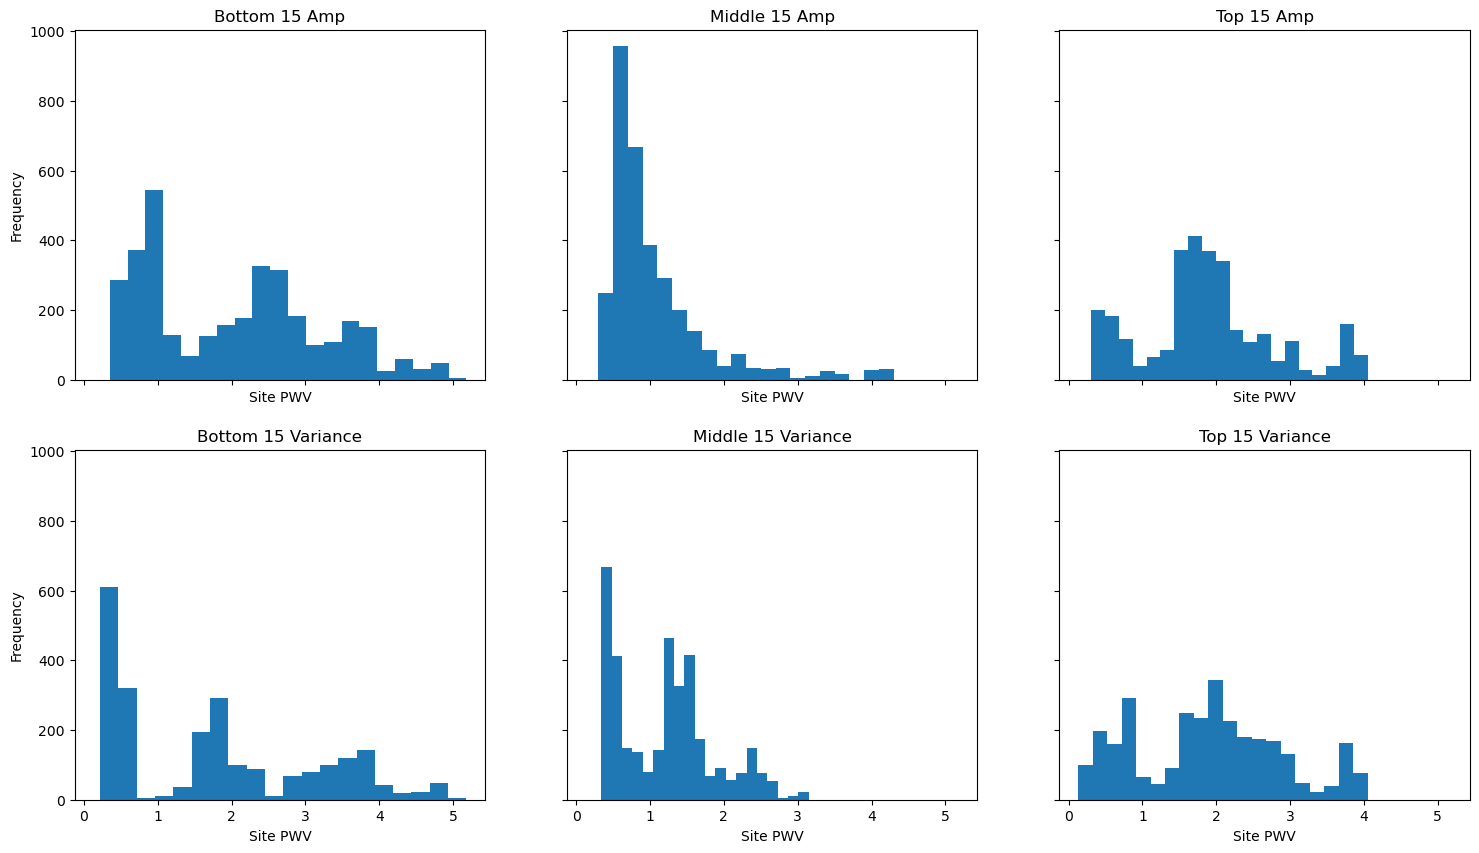

In [59]:
fig, ax = plt.subplots(2,3, sharey=True, sharex=True, figsize=(18,10))
ax[0][0].hist(bottom_15_data['site_pwv'], bins=20)
ax[0][0].set_ylabel("Frequency")
ax[0][0].set_xlabel("Site PWV")
ax[0][0].set_title("Bottom 15 Amp")
ax[0][1].hist(median15_data['site_pwv'], bins=20)
ax[0][1].set_xlabel("Site PWV")
ax[0][1].set_title("Middle 15 Amp")
ax[0][2].hist(top15_data['site_pwv'], bins=20)
ax[0][2].set_xlabel("Site PWV")
ax[0][2].set_title("Top 15 Amp")

ax[1][0].hist(bottom15var_data['site_pwv'], bins=20)
ax[1][0].set_ylabel("Frequency")
ax[1][0].set_xlabel("Site PWV")
ax[1][0].set_title("Bottom 15 Variance")
ax[1][1].hist(median15var_data['site_pwv'], bins=20)
ax[1][1].set_xlabel("Site PWV")
ax[1][1].set_title("Middle 15 Variance")
ax[1][2].hist(top15var_data['site_pwv'], bins=20)
ax[1][2].set_xlabel("Site PWV")
ax[1][2].set_title("Top 15 Variance")

(19905.0, 20332.0)

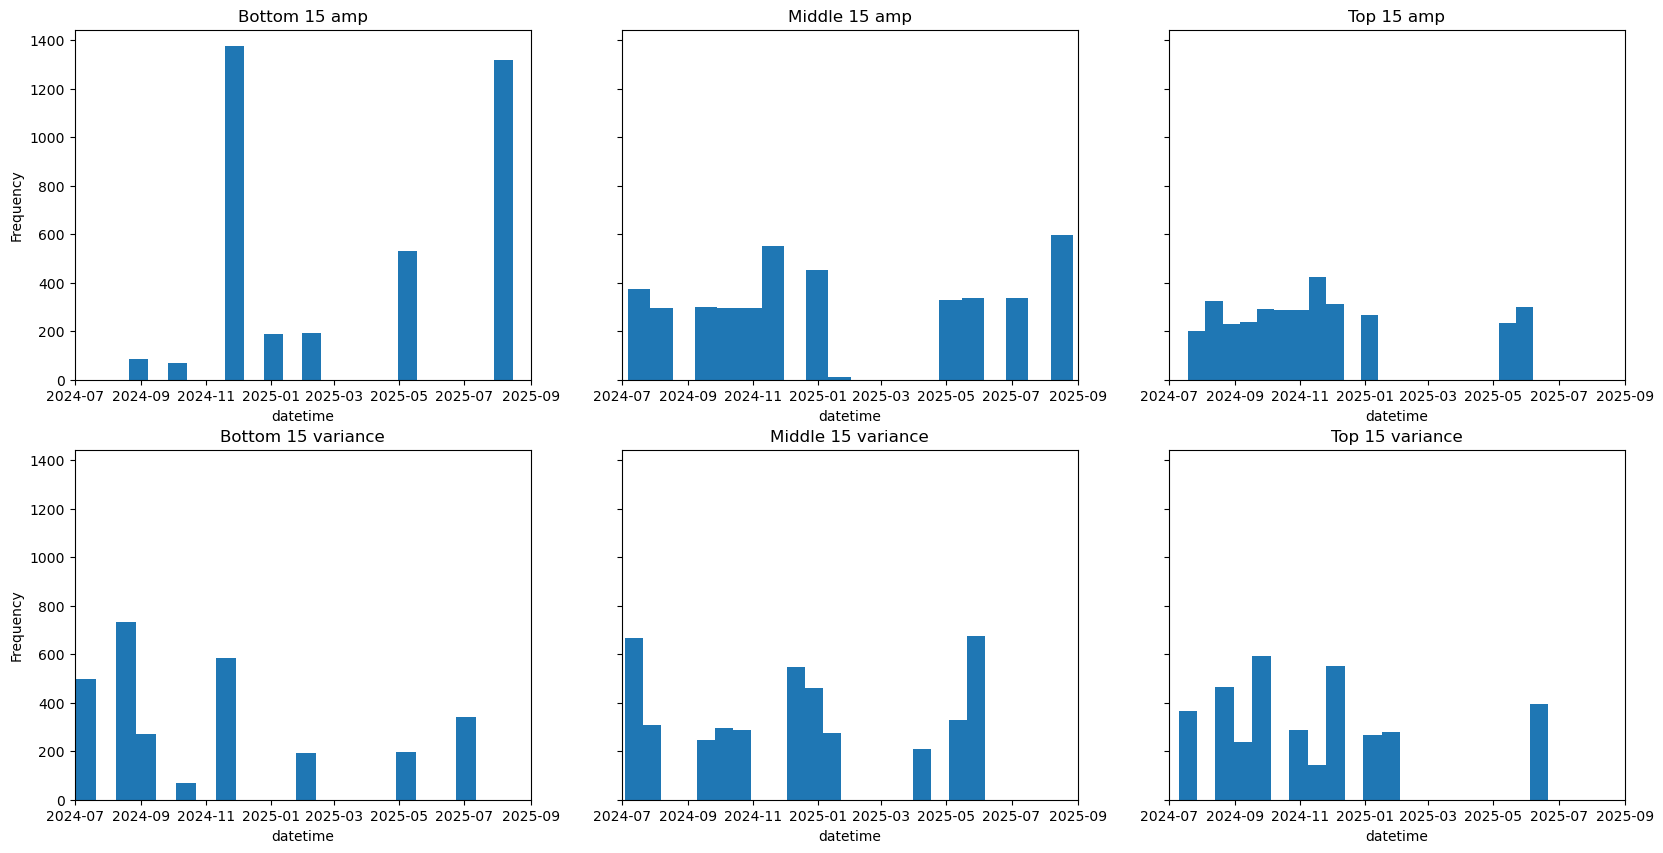

In [62]:
fig, ax = plt.subplots(2,3, sharey=True, figsize=(20,10))
ax[0][0].hist(bottom_15_data['datetime'], bins=20)
ax[0][0].set_ylabel("Frequency")
ax[0][0].set_xlabel("datetime")
ax[0][0].set_title("Bottom 15 amp")
ax[0][0].set_xlim(datetime(2024, 7, 1, 0, 0),  # start
    datetime(2025, 9, 1, 0, 0))
ax[0][1].hist(median15_data['datetime'], bins=20)
ax[0][1].set_xlabel("datetime")
ax[0][1].set_title("Middle 15 amp")
ax[0][1].set_xlim(datetime(2024, 7, 1, 0, 0),  # start
    datetime(2025, 9, 1, 0, 0))
ax[0][2].hist(top15_data['datetime'], bins=20)
ax[0][2].set_xlabel("datetime")
ax[0][2].set_title("Top 15 amp")
ax[0][2].set_xlim(datetime(2024, 7, 1, 0, 0),  # start
    datetime(2025, 9, 1, 0, 0))

ax[1][0].hist(bottom15var_data['datetime'], bins=20)
ax[1][0].set_ylabel("Frequency")
ax[1][0].set_xlabel("datetime")
ax[1][0].set_title("Bottom 15 variance")
ax[1][0].set_xlim(datetime(2024, 7, 1, 0, 0),  # start
    datetime(2025, 9, 1, 0, 0))
ax[1][1].hist(median15var_data['datetime'], bins=20)
ax[1][1].set_xlabel("datetime")
ax[1][1].set_title("Middle 15 variance")
ax[1][1].set_xlim(datetime(2024, 7, 1, 0, 0),  # start
    datetime(2025, 9, 1, 0, 0))
ax[1][2].hist(top15var_data['datetime'], bins=20)
ax[1][2].set_xlabel("datetime")
ax[1][2].set_title("Top 15 variance")
ax[1][2].set_xlim(datetime(2024, 7, 1, 0, 0),  # start
    datetime(2025, 9, 1, 0, 0))

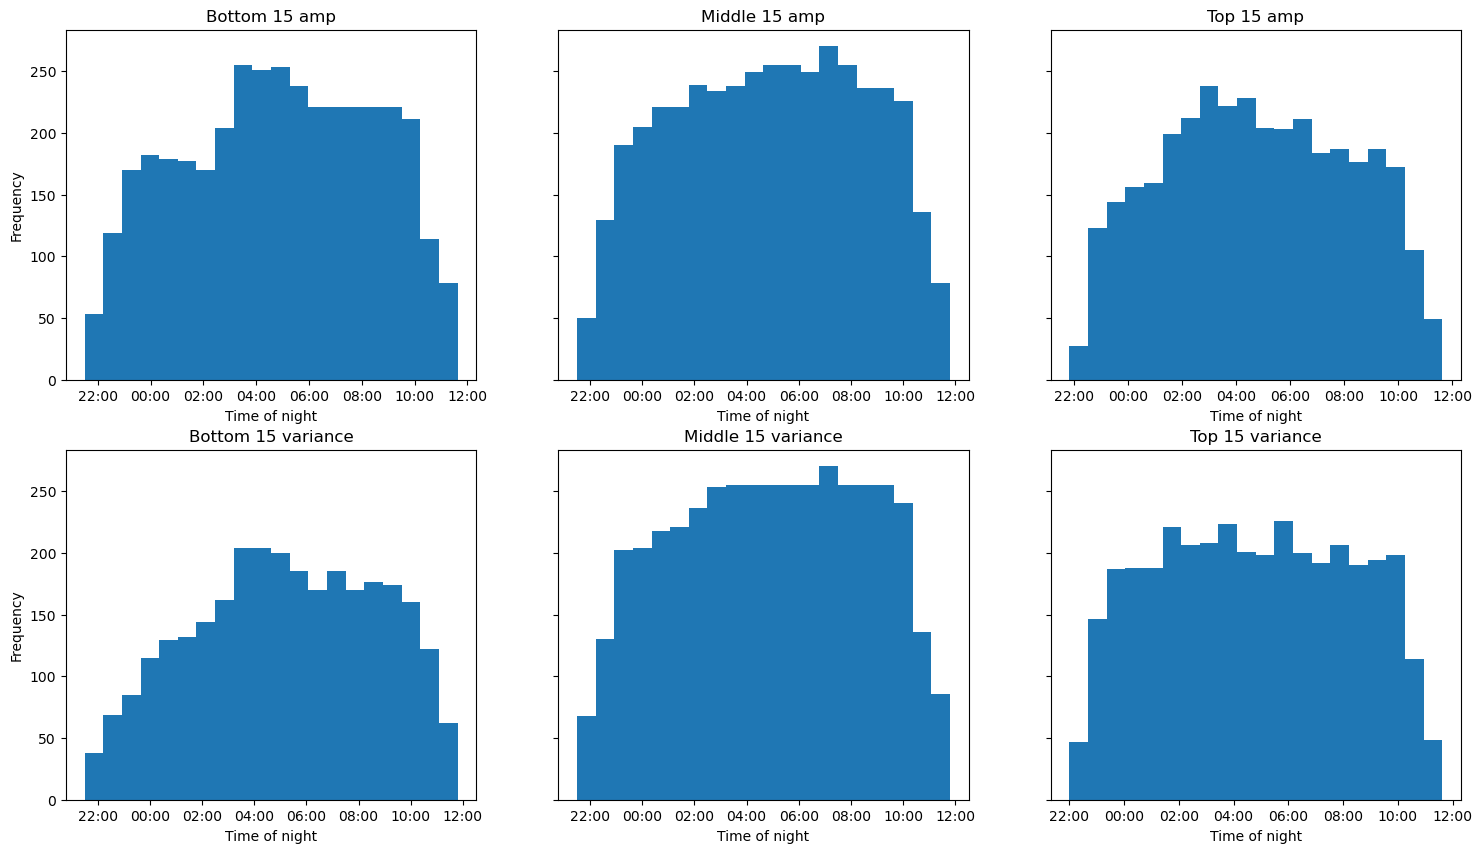

In [64]:
fig, ax = plt.subplots(2,3, sharey=True, figsize=(18,10))
# Format x-axis to display clock time (handles 24+ hours)
def fmt_time(x, pos):
    total_hours = x / 3600
    h = int(total_hours % 24)  # Wrap hours back to 0-23
    m = int((x % 3600) // 60)
    return f"{h:02d}:{m:02d}"

ax[0][0].hist(bottom_15_data['time_of_night_shifted'], bins=20)
ax[0][0].set_ylabel("Frequency")
ax[0][0].set_xlabel("Time of night")
ax[0][0].set_title("Bottom 15 amp")

ax[0][1].hist(median15_data['time_of_night_shifted'], bins=20)
ax[0][1].set_xlabel("Time of night")
ax[0][1].set_title("Middle 15 amp")

ax[0][2].hist(top15_data['time_of_night_shifted'], bins=20)
ax[0][2].set_xlabel("Time of night")
ax[0][2].set_title("Top 15 amp")

ax[1][0].hist(bottom15var_data['time_of_night_shifted'], bins=20)
ax[1][0].set_ylabel("Frequency")
ax[1][0].set_xlabel("Time of night")
ax[1][0].set_title("Bottom 15 variance")

ax[1][1].hist(median15var_data['time_of_night_shifted'], bins=20)
ax[1][1].set_xlabel("Time of night")
ax[1][1].set_title("Middle 15 variance")

ax[1][2].hist(top15var_data['time_of_night_shifted'], bins=20)
ax[1][2].set_xlabel("Time of night")
ax[1][2].set_title("Top 15 variance")

# Apply formatting to all three axes
for a in ax[0]:
    a.xaxis.set_major_locator(MultipleLocator(2*3600))
    a.xaxis.set_major_formatter(FuncFormatter(fmt_time))
for a in ax[1]:
    a.xaxis.set_major_locator(MultipleLocator(2*3600))
    a.xaxis.set_major_formatter(FuncFormatter(fmt_time))

Text(0, 0.5, '2f amp variance')

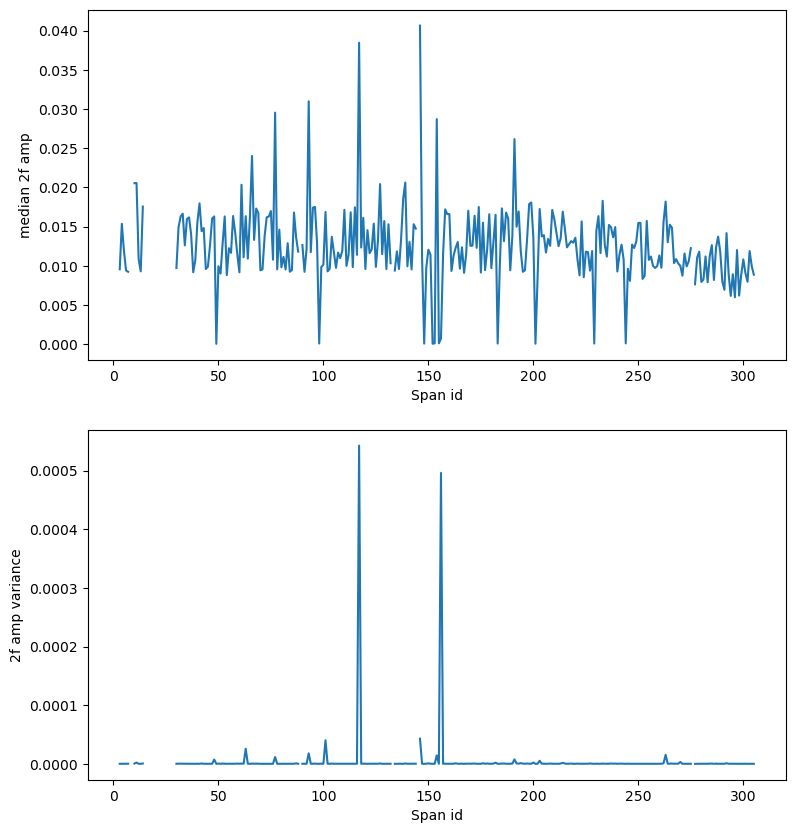

In [69]:
fig, ax = plt.subplots(2,1, figsize=(9,10))
ax[0].plot(pmed[89])
ax[0].set_xlabel("Span id")
ax[0].set_ylabel("median 2f amp")

ax[1].plot(pvar[89])
ax[1].set_xlabel("Span id")
ax[1].set_ylabel("2f amp variance")

## other

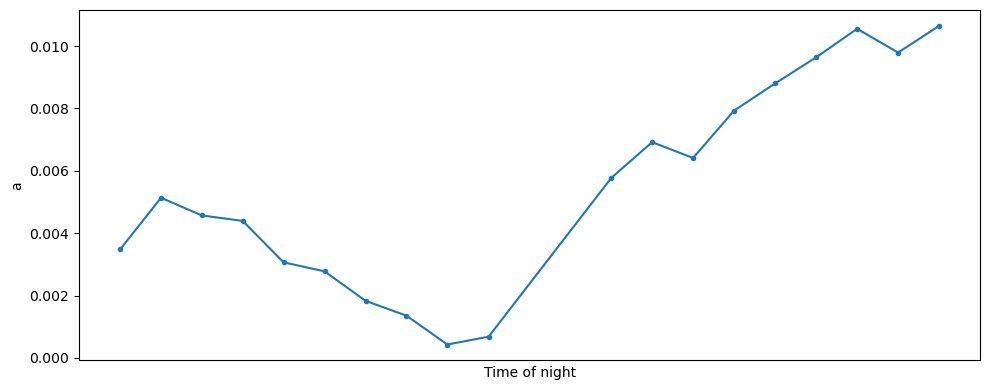

In [64]:
# Convert Unix timestamp to datetime
span_3["datetime"] = pd.to_datetime(span_3["timestamp"], unit="s").dt.round("1s")

# Seconds since the observing day starts
dt = span_3["datetime"]

# Define observing day (noon to noon)
span_3['obs_time'] = (span_3["datetime"] - pd.Timedelta(hours=12)).dt.date

# Calculate seconds since midnight
span_3["time_of_night"] = (
    dt.dt.hour * 3600
    + dt.dt.minute * 60
    + dt.dt.second
    + dt.dt.microsecond / 1e6
)

# Shift so times wrap continuously through midnight
# Times before noon (00:00-11:59) get 24 hours added to appear after evening times
span_3["time_of_night_shifted"] = span_3["time_of_night"].copy()
span_3.loc[span_3["time_of_night"] < 12*3600, "time_of_night_shifted"] += 24*3600

# Plot
plt.figure(figsize=(10, 4))
plt.plot(span_3["time_of_night_shifted"], span_3["a"], ".-")

# Format x-axis to display clock time (handles 24+ hours)
def fmt_time(x, pos):
    total_hours = x / 3600
    h = int(total_hours % 24)  # Wrap hours back to 0-23
    m = int((x % 3600) // 60)
    return f"{h:02d}:{m:02d}"

ax = plt.gca()
ax.xaxis.set_major_locator(MultipleLocator(2*3600))  # Every 2 hours
ax.xaxis.set_major_formatter(FuncFormatter(fmt_time))

plt.xlabel("Time of night")
plt.ylabel("a")
plt.tight_layout()
plt.show()

## Det 359

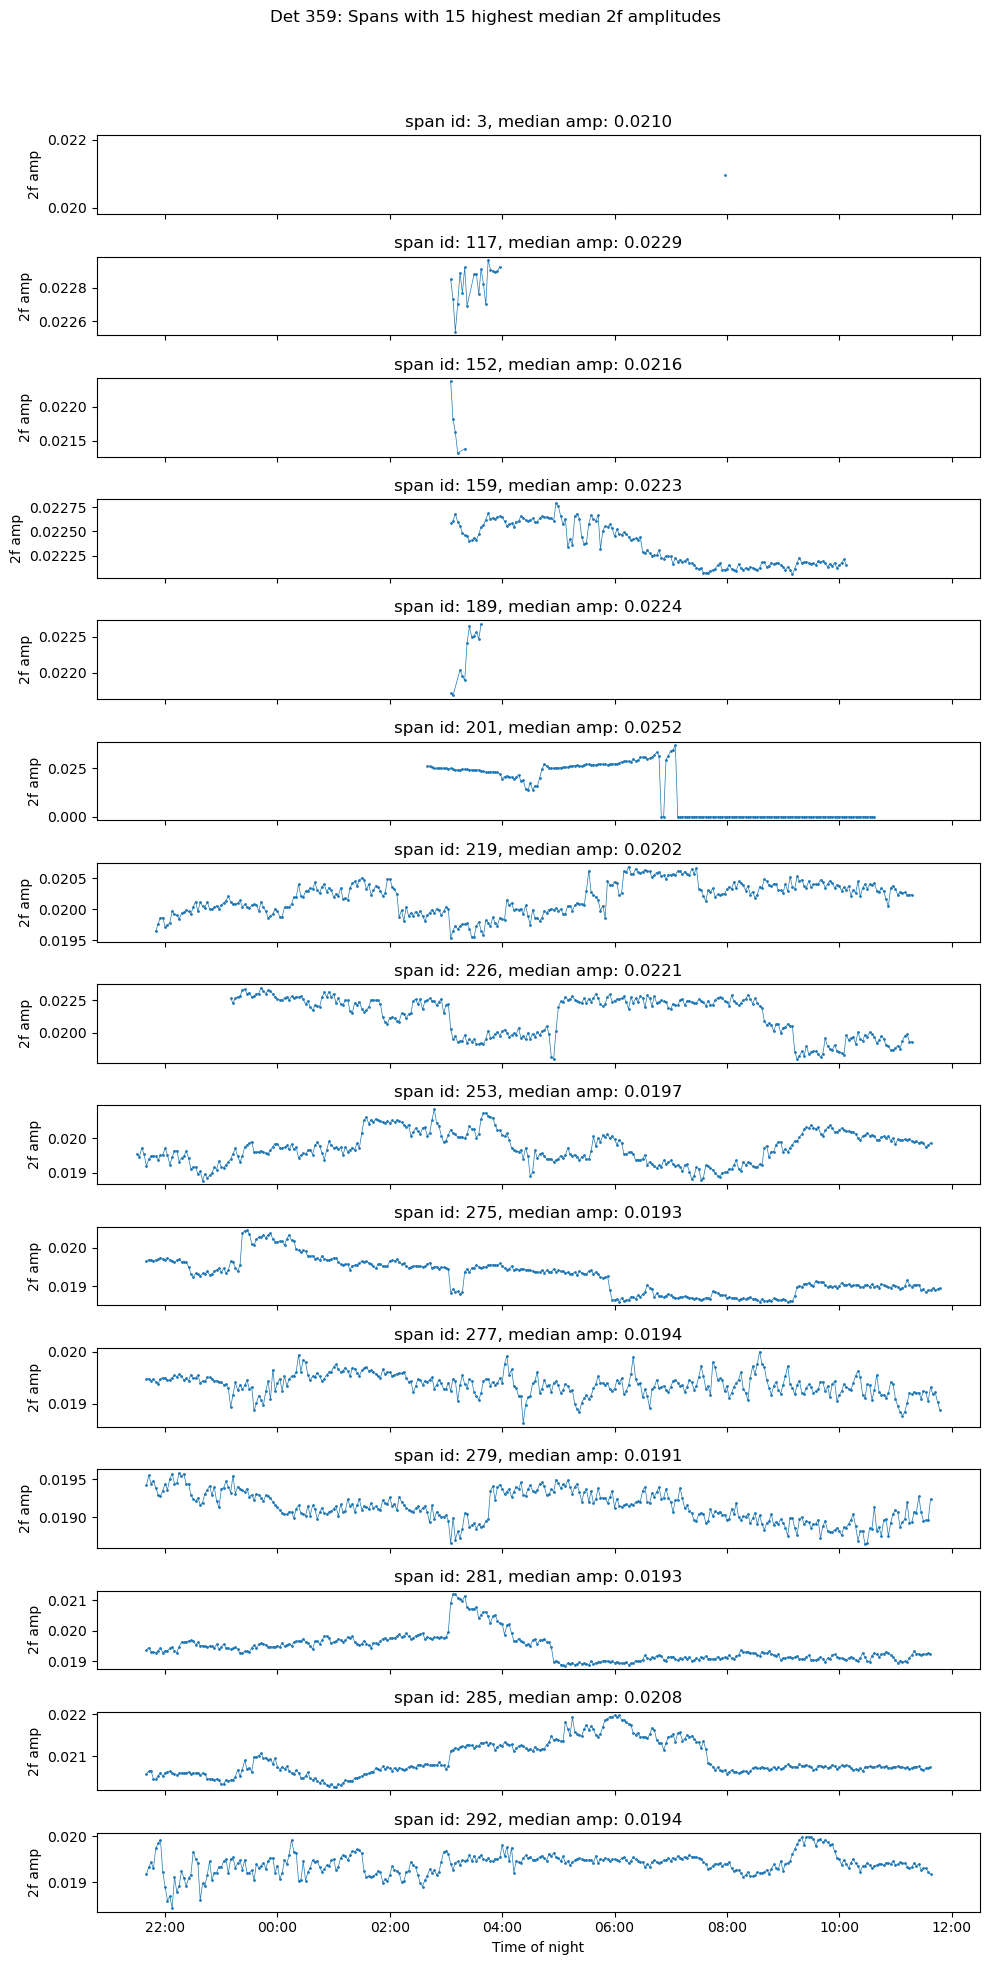

In [92]:
det_359 = full_pf[full_pf['uid']==359].copy()

top15_span_ids = np.argsort(np.nan_to_num(pmed[359], nan=-np.inf))[::-1][:15]
bottom15_span_ids = np.argsort(np.nan_to_num(pmed[359], nan=np.inf))[:15]
median15_span_ids = np.argsort(np.abs(pmed[359] - np.nanmedian(pmed[359])))[:15]

# Convert Unix timestamp to datetime
det_359["datetime"] = pd.to_datetime(det_359["timestamp"], unit="s").dt.round("1s")

# Seconds since the observing day starts
dt = det_359["datetime"]

# Define observing day (noon to noon)
det_359['obs_time'] = (det_359["datetime"] - pd.Timedelta(hours=12)).dt.date

# Calculate seconds since midnight
det_359["time_of_night"] = (
    dt.dt.hour * 3600
    + dt.dt.minute * 60
    + dt.dt.second
    + dt.dt.microsecond / 1e6
)

# Shift so times wrap continuously through midnight
# Times before noon (00:00-11:59) get 24 hours added to appear after evening times
det_359["time_of_night_shifted"] = det_359["time_of_night"].copy()
det_359.loc[det_359["time_of_night"] < 12*3600, "time_of_night_shifted"] += 24*3600
top15_data = det_359[det_359["span_id"].isin(top15_span_ids)]

# Plot
#plt.figure(figsize=(10, 4))
fig, ax = plt.subplots(15,1, sharex=True, figsize=(10,20))

#plt.plot(det_359["time_of_night_shifted"], det_359["a"], ".-")

i = 0
for span_id, group in top15_data.groupby("span_id"):
    ax[i].plot(
        group["time_of_night_shifted"],
        group["a"],
        ".-",
        linewidth=0.5,
        markersize=2,
        label=str(span_id)
    )
    ax[i].set_ylabel("2f amp")
    ax[i].set_title(f"span id: {span_id}, median amp: {pmed[359][span_id]:.4f}")
    i +=1

# Format x-axis to display clock time (handles 24+ hours)
def fmt_time(x, pos):
    total_hours = x / 3600
    h = int(total_hours % 24)  # Wrap hours back to 0-23
    m = int((x % 3600) // 60)
    return f"{h:02d}:{m:02d}"

ax = plt.gca()
ax.xaxis.set_major_locator(MultipleLocator(2*3600))  # Every 2 hours
ax.xaxis.set_major_formatter(FuncFormatter(fmt_time))

plt.xlabel("Time of night")
fig.suptitle("Det 359: Spans with 15 highest median 2f amplitudes", y=0.98)
fig.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

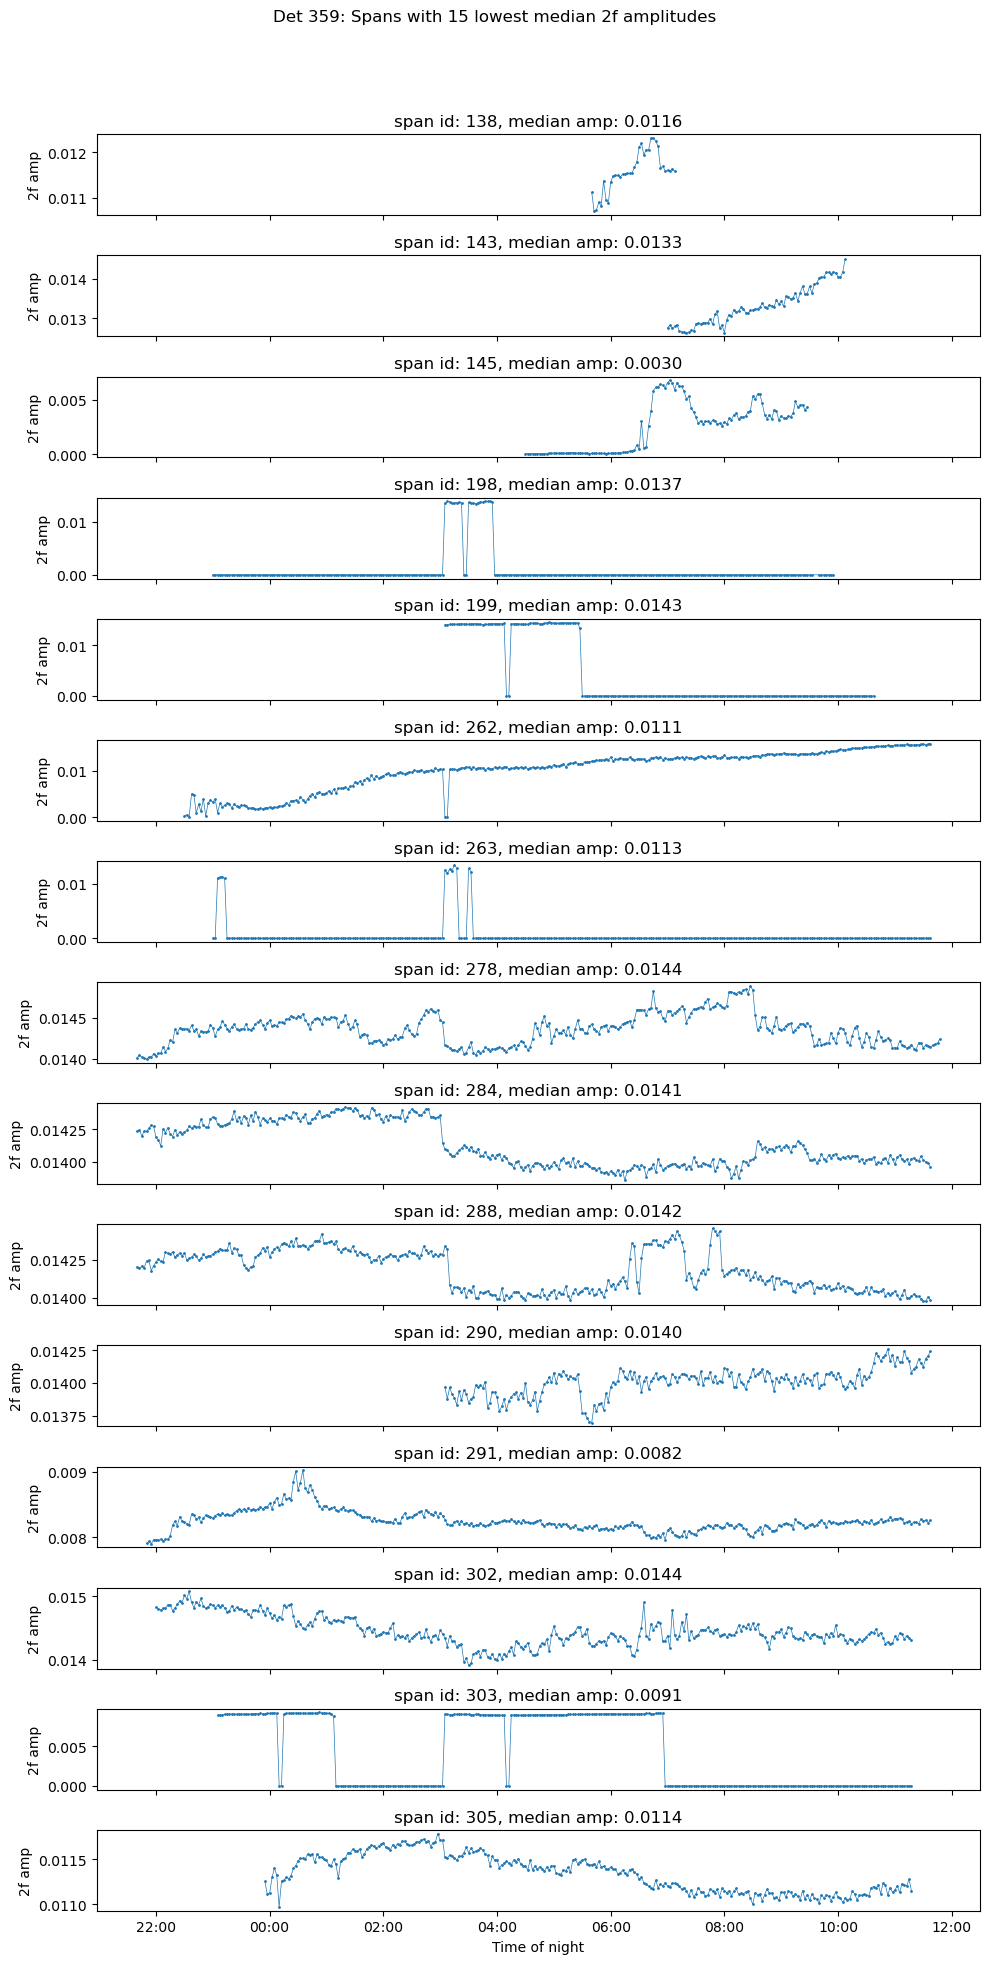

In [71]:
# Plot
bottom15_data = det_359[det_359["span_id"].isin(bottom15_span_ids)]
#plt.figure(figsize=(10, 4))
fig, ax = plt.subplots(15,1, sharex=True, figsize=(10,20))

#plt.plot(det_359["time_of_night_shifted"], det_359["a"], ".-")

i = 0
for span_id, group in bottom15_data.groupby("span_id"):
    ax[i].plot(
        group["time_of_night_shifted"],
        group["a"],
        ".-",
        linewidth=0.5,
        markersize=2,
        label=str(span_id)
    )
    ax[i].set_ylabel("2f amp")
    ax[i].set_title(f"span id: {span_id}, median amp: {pmed[359][span_id]:.4f}")
    i +=1

# Format x-axis to display clock time (handles 24+ hours)
def fmt_time(x, pos):
    total_hours = x / 3600
    h = int(total_hours % 24)  # Wrap hours back to 0-23
    m = int((x % 3600) // 60)
    return f"{h:02d}:{m:02d}"

ax = plt.gca()
ax.xaxis.set_major_locator(MultipleLocator(2*3600))  # Every 2 hours
ax.xaxis.set_major_formatter(FuncFormatter(fmt_time))

plt.xlabel("Time of night")
fig.suptitle("Det 359: Spans with 15 lowest median 2f amplitudes", y=0.98)
fig.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [93]:
median15_data = det_359[det_359["span_id"].isin(median15_span_ids)]

In [94]:
top15var_span_ids = np.argsort(np.nan_to_num(pvar[359], nan=-np.inf))[::-1][:15]
bottom15var_span_ids = np.argsort(np.nan_to_num(pvar[359], nan=np.inf))[:15]
median15var_span_ids = np.argsort(np.abs(pvar[359] - np.nanmedian(pvar[359])))[:15]

top15var_data = det_359[det_359["span_id"].isin(top15var_span_ids)]
median15var_data = det_359[det_359["span_id"].isin(median15var_span_ids)]
bottom15var_data = det_359[det_359["span_id"].isin(bottom15var_span_ids)]

Text(0.5, 1.0, 'Top 15 Variance')

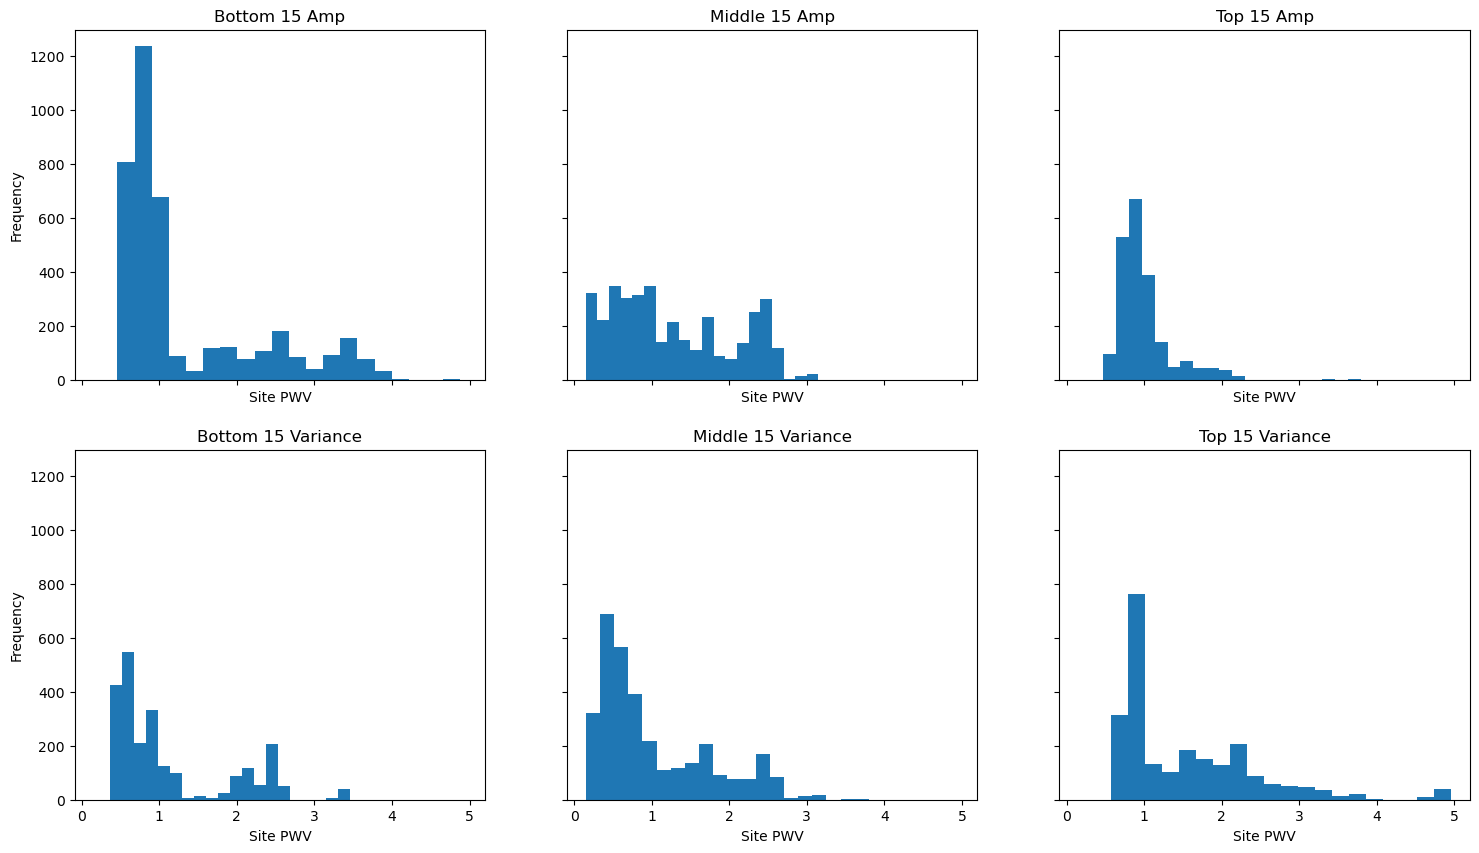

In [95]:
fig, ax = plt.subplots(2,3, sharey=True, sharex=True, figsize=(18,10))
ax[0][0].hist(bottom15_data['site_pwv'], bins=20)
ax[0][0].set_ylabel("Frequency")
ax[0][0].set_xlabel("Site PWV")
ax[0][0].set_title("Bottom 15 Amp")
ax[0][1].hist(median15_data['site_pwv'], bins=20)
ax[0][1].set_xlabel("Site PWV")
ax[0][1].set_title("Middle 15 Amp")
ax[0][2].hist(top15_data['site_pwv'], bins=20)
ax[0][2].set_xlabel("Site PWV")
ax[0][2].set_title("Top 15 Amp")

ax[1][0].hist(bottom15var_data['site_pwv'], bins=20)
ax[1][0].set_ylabel("Frequency")
ax[1][0].set_xlabel("Site PWV")
ax[1][0].set_title("Bottom 15 Variance")
ax[1][1].hist(median15var_data['site_pwv'], bins=20)
ax[1][1].set_xlabel("Site PWV")
ax[1][1].set_title("Middle 15 Variance")
ax[1][2].hist(top15var_data['site_pwv'], bins=20)
ax[1][2].set_xlabel("Site PWV")
ax[1][2].set_title("Top 15 Variance")

(19905.0, 20332.0)

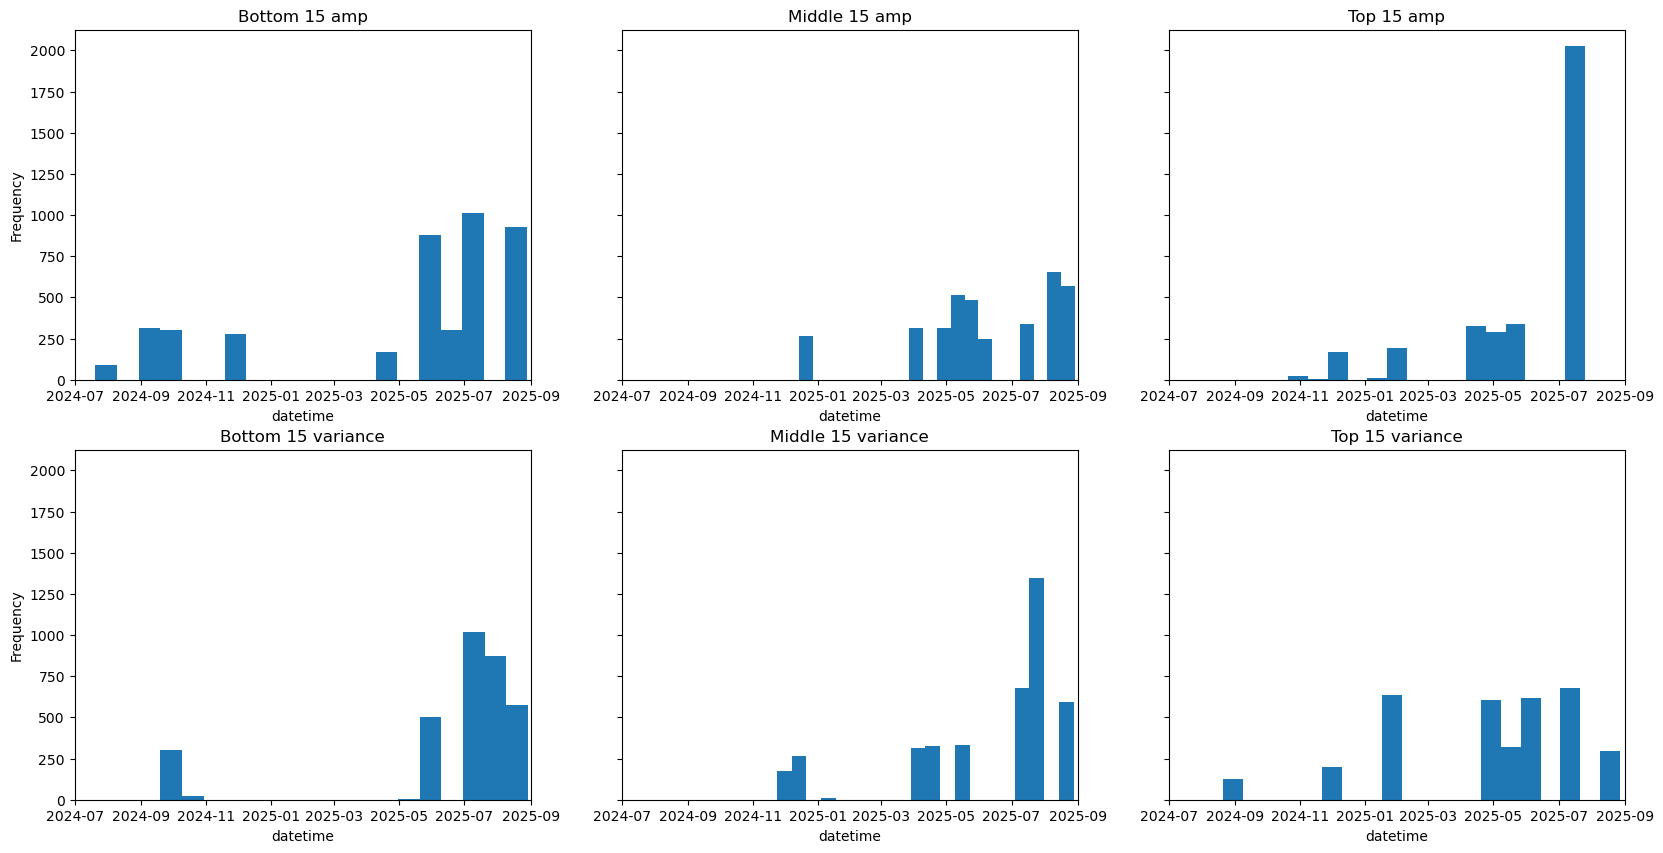

In [96]:
fig, ax = plt.subplots(2,3, sharey=True, figsize=(20,10))
ax[0][0].hist(bottom15_data['datetime'], bins=20)
ax[0][0].set_ylabel("Frequency")
ax[0][0].set_xlabel("datetime")
ax[0][0].set_title("Bottom 15 amp")
ax[0][0].set_xlim(datetime(2024, 7, 1, 0, 0),  # start
    datetime(2025, 9, 1, 0, 0))
ax[0][1].hist(median15_data['datetime'], bins=20)
ax[0][1].set_xlabel("datetime")
ax[0][1].set_title("Middle 15 amp")
ax[0][1].set_xlim(datetime(2024, 7, 1, 0, 0),  # start
    datetime(2025, 9, 1, 0, 0))
ax[0][2].hist(top15_data['datetime'], bins=20)
ax[0][2].set_xlabel("datetime")
ax[0][2].set_title("Top 15 amp")
ax[0][2].set_xlim(datetime(2024, 7, 1, 0, 0),  # start
    datetime(2025, 9, 1, 0, 0))

ax[1][0].hist(bottom15var_data['datetime'], bins=20)
ax[1][0].set_ylabel("Frequency")
ax[1][0].set_xlabel("datetime")
ax[1][0].set_title("Bottom 15 variance")
ax[1][0].set_xlim(datetime(2024, 7, 1, 0, 0),  # start
    datetime(2025, 9, 1, 0, 0))
ax[1][1].hist(median15var_data['datetime'], bins=20)
ax[1][1].set_xlabel("datetime")
ax[1][1].set_title("Middle 15 variance")
ax[1][1].set_xlim(datetime(2024, 7, 1, 0, 0),  # start
    datetime(2025, 9, 1, 0, 0))
ax[1][2].hist(top15var_data['datetime'], bins=20)
ax[1][2].set_xlabel("datetime")
ax[1][2].set_title("Top 15 variance")
ax[1][2].set_xlim(datetime(2024, 7, 1, 0, 0),  # start
    datetime(2025, 9, 1, 0, 0))

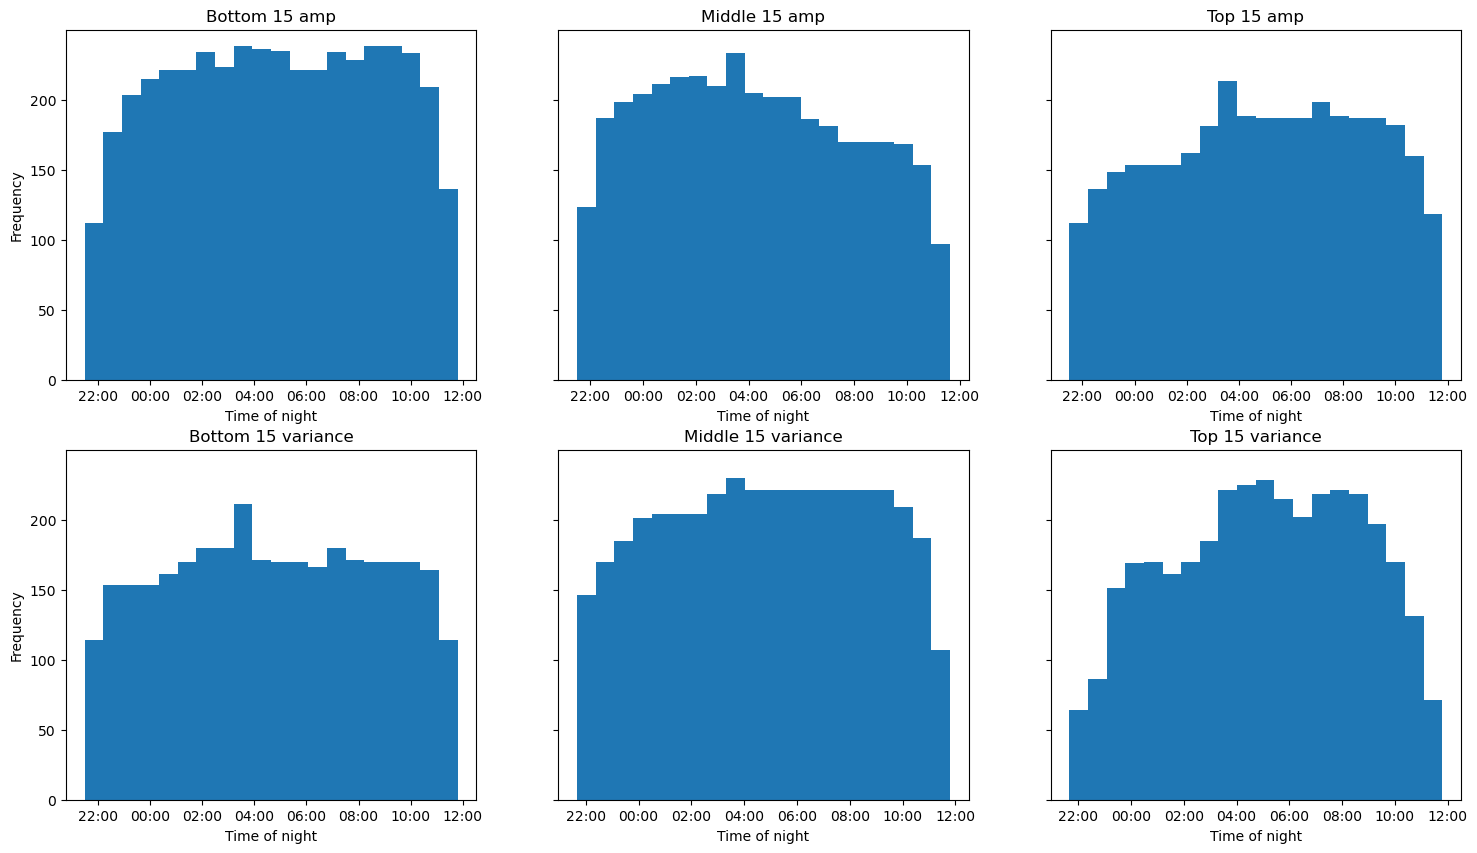

In [97]:
fig, ax = plt.subplots(2,3, sharey=True, figsize=(18,10))
# Format x-axis to display clock time (handles 24+ hours)
def fmt_time(x, pos):
    total_hours = x / 3600
    h = int(total_hours % 24)  # Wrap hours back to 0-23
    m = int((x % 3600) // 60)
    return f"{h:02d}:{m:02d}"

ax[0][0].hist(bottom15_data['time_of_night_shifted'], bins=20)
ax[0][0].set_ylabel("Frequency")
ax[0][0].set_xlabel("Time of night")
ax[0][0].set_title("Bottom 15 amp")

ax[0][1].hist(median15_data['time_of_night_shifted'], bins=20)
ax[0][1].set_xlabel("Time of night")
ax[0][1].set_title("Middle 15 amp")

ax[0][2].hist(top15_data['time_of_night_shifted'], bins=20)
ax[0][2].set_xlabel("Time of night")
ax[0][2].set_title("Top 15 amp")

ax[1][0].hist(bottom15var_data['time_of_night_shifted'], bins=20)
ax[1][0].set_ylabel("Frequency")
ax[1][0].set_xlabel("Time of night")
ax[1][0].set_title("Bottom 15 variance")

ax[1][1].hist(median15var_data['time_of_night_shifted'], bins=20)
ax[1][1].set_xlabel("Time of night")
ax[1][1].set_title("Middle 15 variance")

ax[1][2].hist(top15var_data['time_of_night_shifted'], bins=20)
ax[1][2].set_xlabel("Time of night")
ax[1][2].set_title("Top 15 variance")

# Apply formatting to all three axes
for a in ax[0]:
    a.xaxis.set_major_locator(MultipleLocator(2*3600))
    a.xaxis.set_major_formatter(FuncFormatter(fmt_time))
for a in ax[1]:
    a.xaxis.set_major_locator(MultipleLocator(2*3600))
    a.xaxis.set_major_formatter(FuncFormatter(fmt_time))

Text(0, 0.5, '2f amp variance')

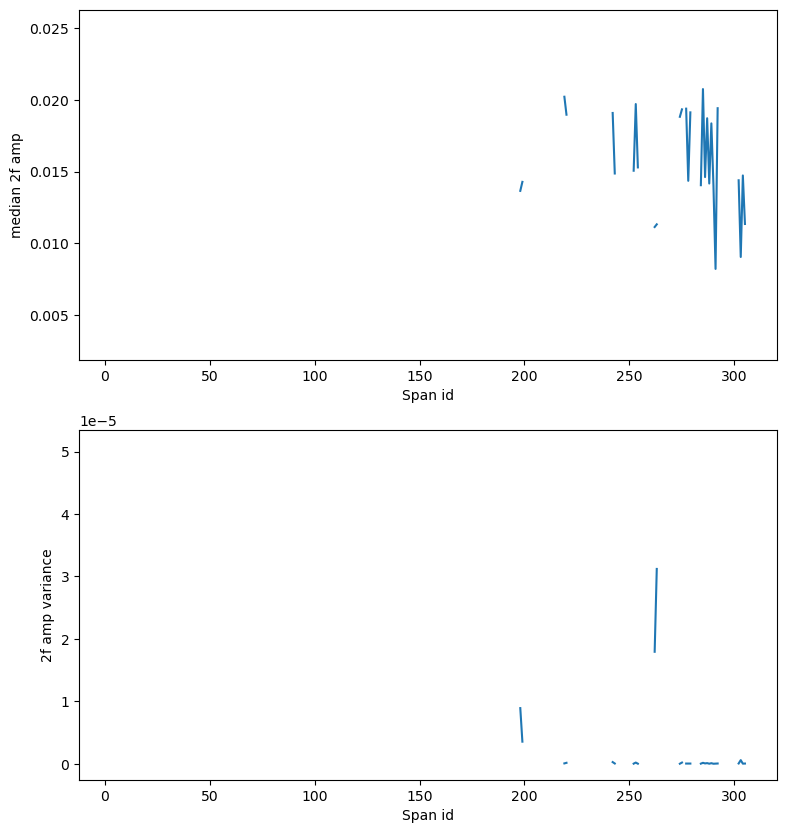

In [79]:
fig, ax = plt.subplots(2,1, figsize=(9,10))
ax[0].plot(pmed[359])
ax[0].set_xlabel("Span id")
ax[0].set_ylabel("median 2f amp")

ax[1].plot(pvar[359])
ax[1].set_xlabel("Span id")
ax[1].set_ylabel("2f amp variance")

### Det 393

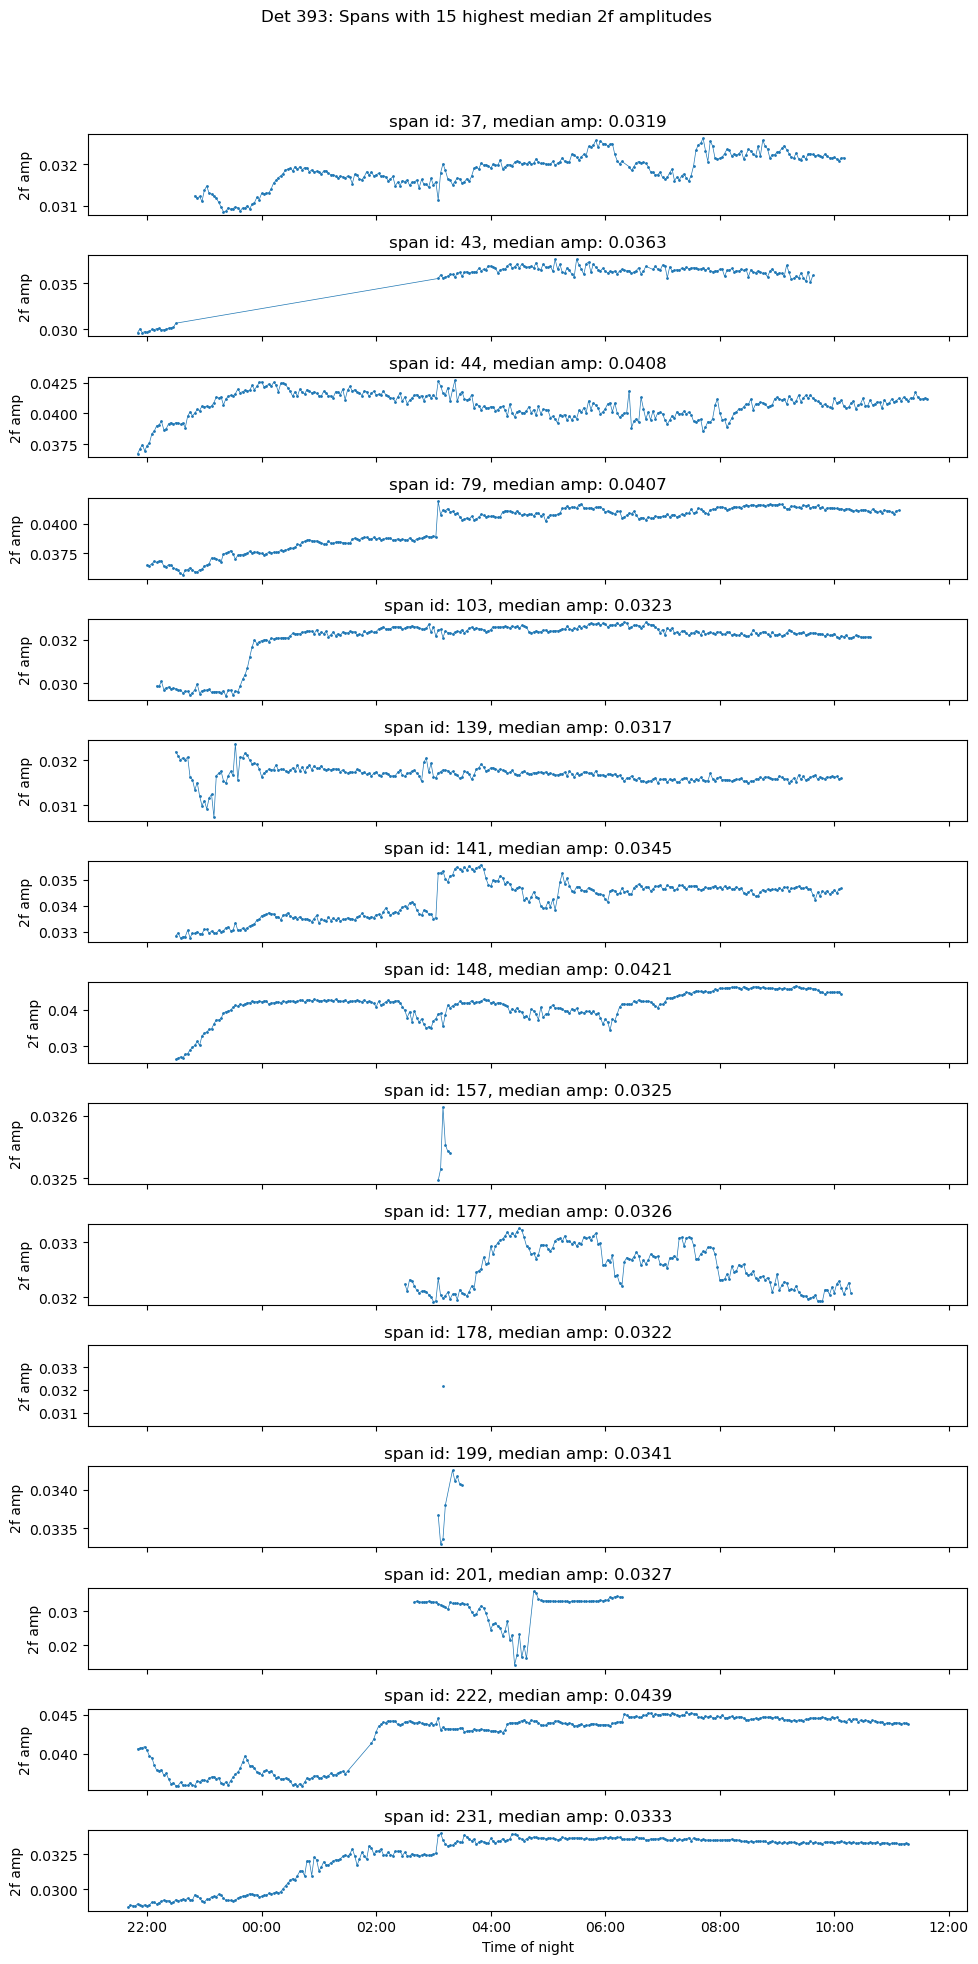

In [80]:
det_393 = full_pf[full_pf['uid']==393].copy()

top15_span_ids = np.argsort(np.nan_to_num(pmed[393], nan=-np.inf))[::-1][:15]
bottom15_span_ids = np.argsort(np.nan_to_num(pmed[393], nan=np.inf))[:15]
median15_span_ids = np.argsort(np.abs(pmed[359] - np.nanmedian(pmed[359])))[:15]

# Convert Unix timestamp to datetime
det_393["datetime"] = pd.to_datetime(det_393["timestamp"], unit="s").dt.round("1s")

# Seconds since the observing day starts
dt = det_393["datetime"]

# Define observing day (noon to noon)
det_393['obs_time'] = (det_393["datetime"] - pd.Timedelta(hours=12)).dt.date

# Calculate seconds since midnight
det_393["time_of_night"] = (
    dt.dt.hour * 3600
    + dt.dt.minute * 60
    + dt.dt.second
    + dt.dt.microsecond / 1e6
)

# Shift so times wrap continuously through midnight
# Times before noon (00:00-11:59) get 24 hours added to appear after evening times
det_393["time_of_night_shifted"] = det_393["time_of_night"].copy()
det_393.loc[det_393["time_of_night"] < 12*3600, "time_of_night_shifted"] += 24*3600
top15_data = det_393[det_393["span_id"].isin(top15_span_ids)]

# Plot
#plt.figure(figsize=(10, 4))
fig, ax = plt.subplots(15,1, sharex=True, figsize=(10,20))

#plt.plot(det_393["time_of_night_shifted"], det_393["a"], ".-")

i = 0
for span_id, group in top15_data.groupby("span_id"):
    ax[i].plot(
        group["time_of_night_shifted"],
        group["a"],
        ".-",
        linewidth=0.5,
        markersize=2,
        label=str(span_id)
    )
    ax[i].set_ylabel("2f amp")
    ax[i].set_title(f"span id: {span_id}, median amp: {pmed[393][span_id]:.4f}")
    i +=1

# Format x-axis to display clock time (handles 24+ hours)
def fmt_time(x, pos):
    total_hours = x / 3600
    h = int(total_hours % 24)  # Wrap hours back to 0-23
    m = int((x % 3600) // 60)
    return f"{h:02d}:{m:02d}"

ax = plt.gca()
ax.xaxis.set_major_locator(MultipleLocator(2*3600))  # Every 2 hours
ax.xaxis.set_major_formatter(FuncFormatter(fmt_time))

plt.xlabel("Time of night")
fig.suptitle("Det 393: Spans with 15 highest median 2f amplitudes", y=0.98)
fig.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

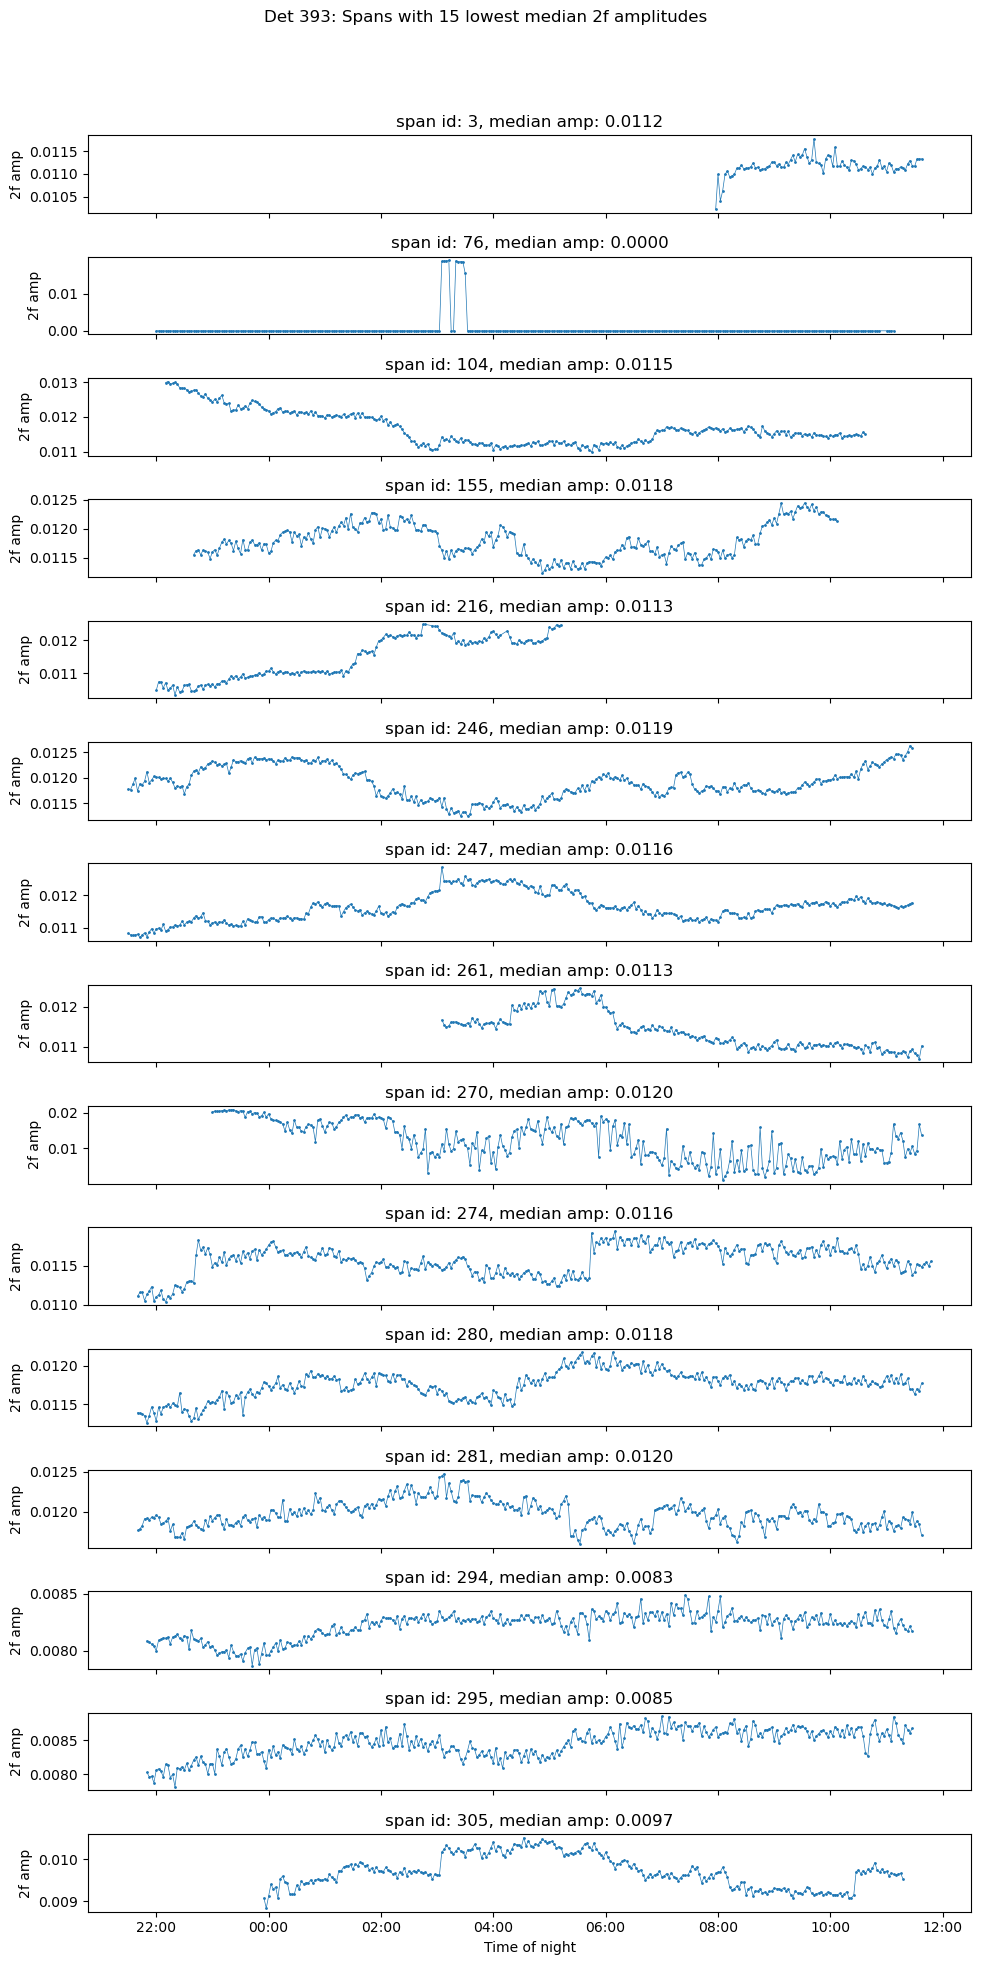

In [81]:
bottom15_data = det_393[det_393["span_id"].isin(bottom15_span_ids)]

# Plot
#plt.figure(figsize=(10, 4))
fig, ax = plt.subplots(15,1, sharex=True, figsize=(10,20))

#plt.plot(det_393["time_of_night_shifted"], det_393["a"], ".-")

i = 0
for span_id, group in bottom15_data.groupby("span_id"):
    ax[i].plot(
        group["time_of_night_shifted"],
        group["a"],
        ".-",
        linewidth=0.5,
        markersize=2,
        label=str(span_id)
    )
    ax[i].set_ylabel("2f amp")
    ax[i].set_title(f"span id: {span_id}, median amp: {pmed[393][span_id]:.4f}")
    i +=1

# Format x-axis to display clock time (handles 24+ hours)
def fmt_time(x, pos):
    total_hours = x / 3600
    h = int(total_hours % 24)  # Wrap hours back to 0-23
    m = int((x % 3600) // 60)
    return f"{h:02d}:{m:02d}"

ax = plt.gca()
ax.xaxis.set_major_locator(MultipleLocator(2*3600))  # Every 2 hours
ax.xaxis.set_major_formatter(FuncFormatter(fmt_time))

plt.xlabel("Time of night")
fig.suptitle("Det 393: Spans with 15 lowest median 2f amplitudes", y=0.98)
fig.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [83]:
median15_data = det_393[det_393["span_id"].isin(median15_span_ids)]

In [84]:
top15var_span_ids = np.argsort(np.nan_to_num(pvar[393], nan=-np.inf))[::-1][:15]
bottom15var_span_ids = np.argsort(np.nan_to_num(pvar[393], nan=np.inf))[:15]
median15var_span_ids = np.argsort(np.abs(pvar[393] - np.nanmedian(pvar[393])))[:15]

top15var_data = det_393[det_393["span_id"].isin(top15var_span_ids)]
median15var_data = det_393[det_393["span_id"].isin(median15var_span_ids)]
bottom15var_data = det_393[det_393["span_id"].isin(bottom15var_span_ids)]

Text(0.5, 1.0, 'Top 15 Variance')

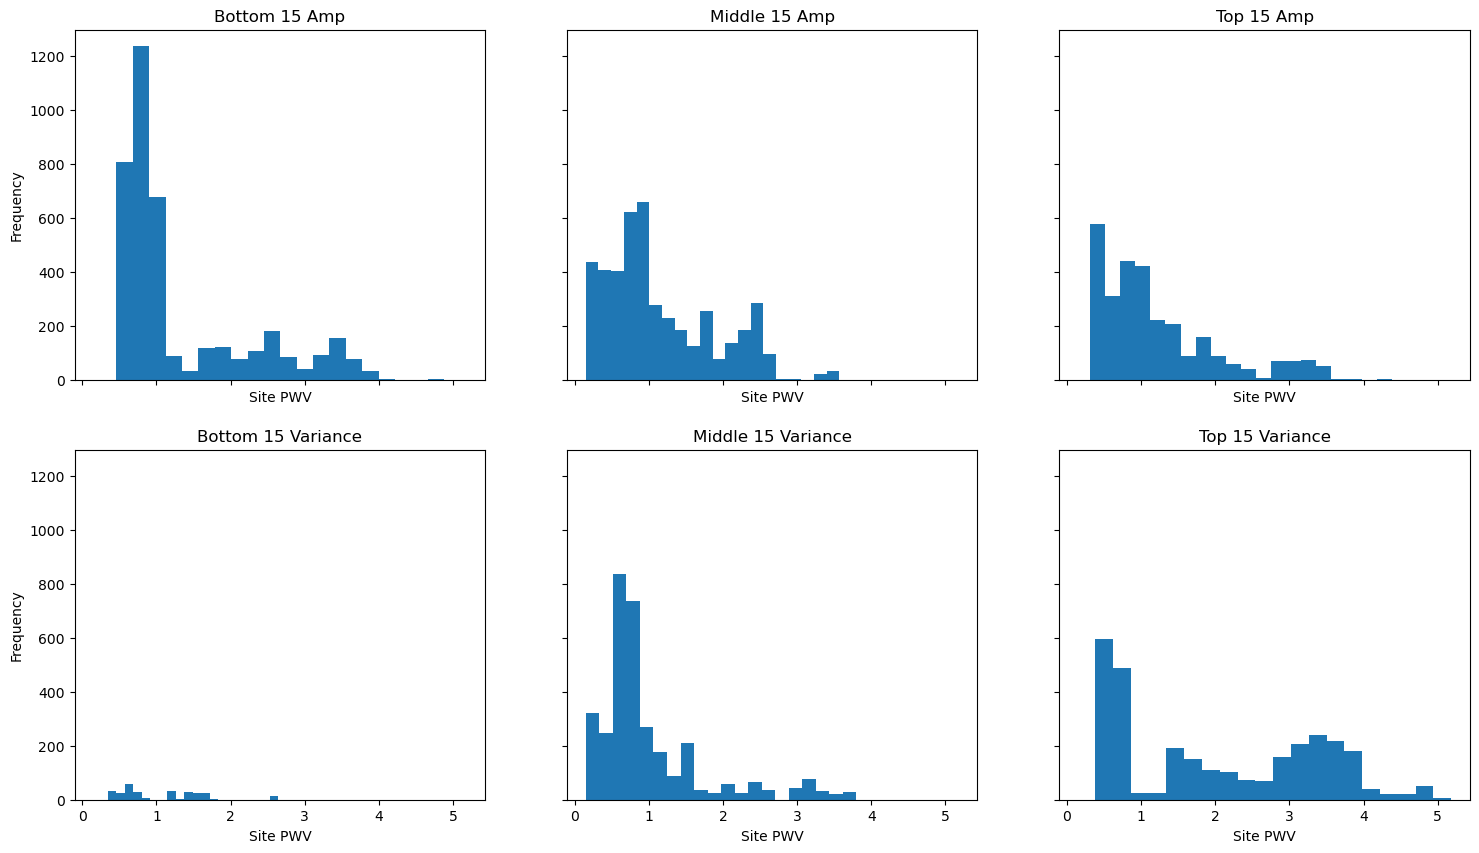

In [87]:
fig, ax = plt.subplots(2,3, sharey=True, sharex=True, figsize=(18,10))
ax[0][0].hist(bottom15_data['site_pwv'], bins=20)
ax[0][0].set_ylabel("Frequency")
ax[0][0].set_xlabel("Site PWV")
ax[0][0].set_title("Bottom 15 Amp")
ax[0][1].hist(median15_data['site_pwv'], bins=20)
ax[0][1].set_xlabel("Site PWV")
ax[0][1].set_title("Middle 15 Amp")
ax[0][2].hist(top15_data['site_pwv'], bins=20)
ax[0][2].set_xlabel("Site PWV")
ax[0][2].set_title("Top 15 Amp")

ax[1][0].hist(bottom15var_data['site_pwv'], bins=20)
ax[1][0].set_ylabel("Frequency")
ax[1][0].set_xlabel("Site PWV")
ax[1][0].set_title("Bottom 15 Variance")
ax[1][1].hist(median15var_data['site_pwv'], bins=20)
ax[1][1].set_xlabel("Site PWV")
ax[1][1].set_title("Middle 15 Variance")
ax[1][2].hist(top15var_data['site_pwv'], bins=20)
ax[1][2].set_xlabel("Site PWV")
ax[1][2].set_title("Top 15 Variance")

(19905.0, 20332.0)

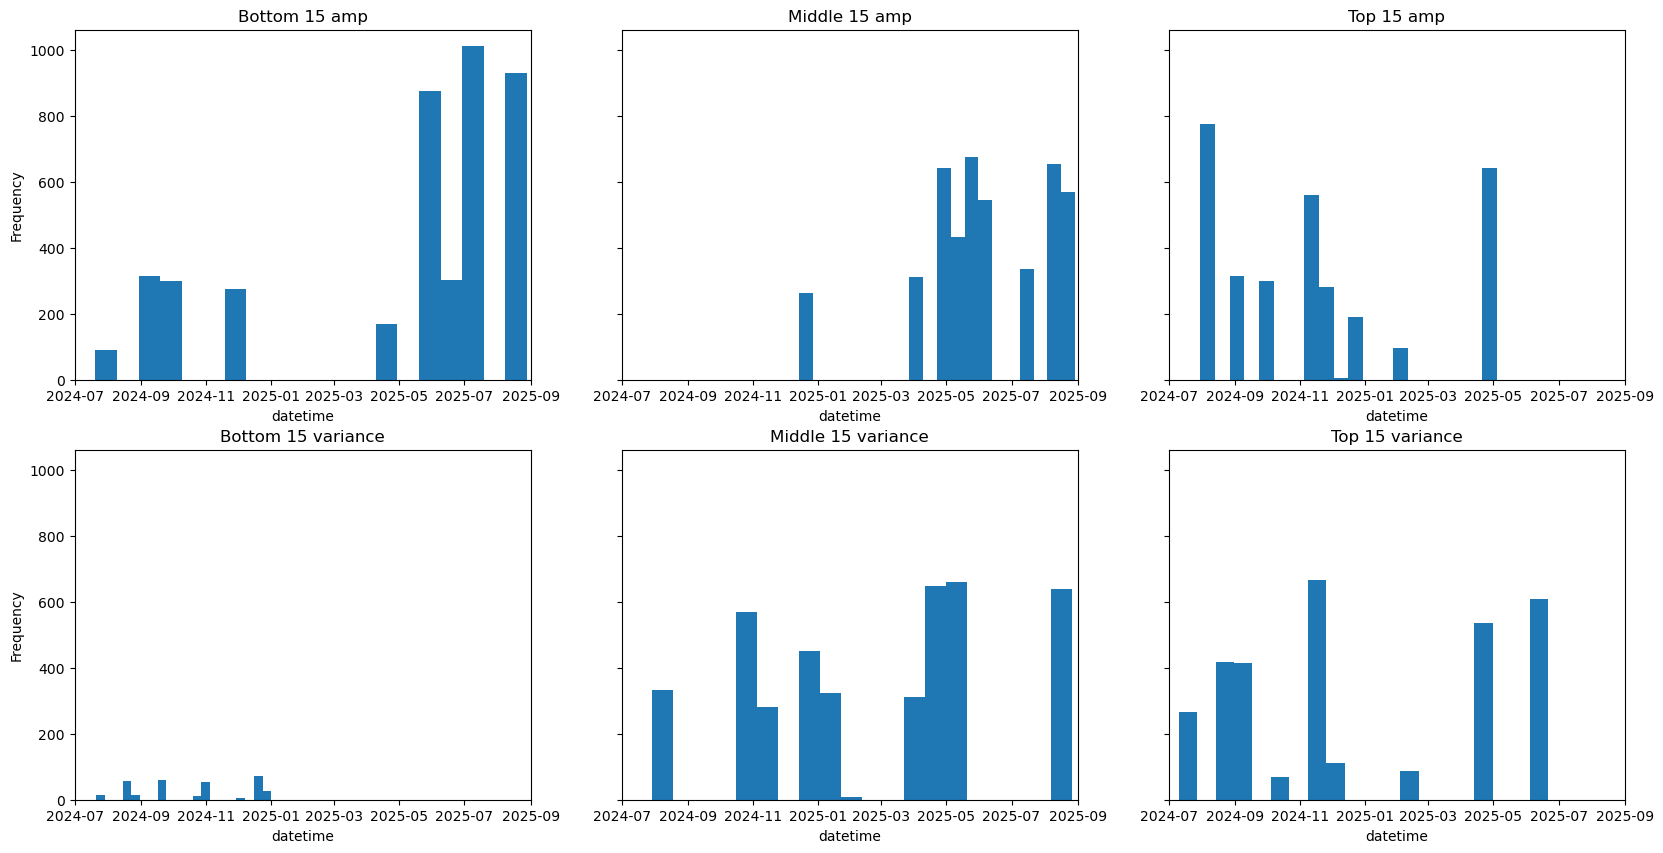

In [90]:
fig, ax = plt.subplots(2,3, sharey=True, figsize=(20,10))
ax[0][0].hist(bottom15_data['datetime'], bins=20)
ax[0][0].set_ylabel("Frequency")
ax[0][0].set_xlabel("datetime")
ax[0][0].set_title("Bottom 15 amp")
ax[0][0].set_xlim(datetime(2024, 7, 1, 0, 0),  # start
    datetime(2025, 9, 1, 0, 0))
ax[0][1].hist(median15_data['datetime'], bins=20)
ax[0][1].set_xlabel("datetime")
ax[0][1].set_title("Middle 15 amp")
ax[0][1].set_xlim(datetime(2024, 7, 1, 0, 0),  # start
    datetime(2025, 9, 1, 0, 0))
ax[0][2].hist(top15_data['datetime'], bins=20)
ax[0][2].set_xlabel("datetime")
ax[0][2].set_title("Top 15 amp")
ax[0][2].set_xlim(datetime(2024, 7, 1, 0, 0),  # start
    datetime(2025, 9, 1, 0, 0))

ax[1][0].hist(bottom15var_data['datetime'], bins=20)
ax[1][0].set_ylabel("Frequency")
ax[1][0].set_xlabel("datetime")
ax[1][0].set_title("Bottom 15 variance")
ax[1][0].set_xlim(datetime(2024, 7, 1, 0, 0),  # start
    datetime(2025, 9, 1, 0, 0))
ax[1][1].hist(median15var_data['datetime'], bins=20)
ax[1][1].set_xlabel("datetime")
ax[1][1].set_title("Middle 15 variance")
ax[1][1].set_xlim(datetime(2024, 7, 1, 0, 0),  # start
    datetime(2025, 9, 1, 0, 0))
ax[1][2].hist(top15var_data['datetime'], bins=20)
ax[1][2].set_xlabel("datetime")
ax[1][2].set_title("Top 15 variance")
ax[1][2].set_xlim(datetime(2024, 7, 1, 0, 0),  # start
    datetime(2025, 9, 1, 0, 0))

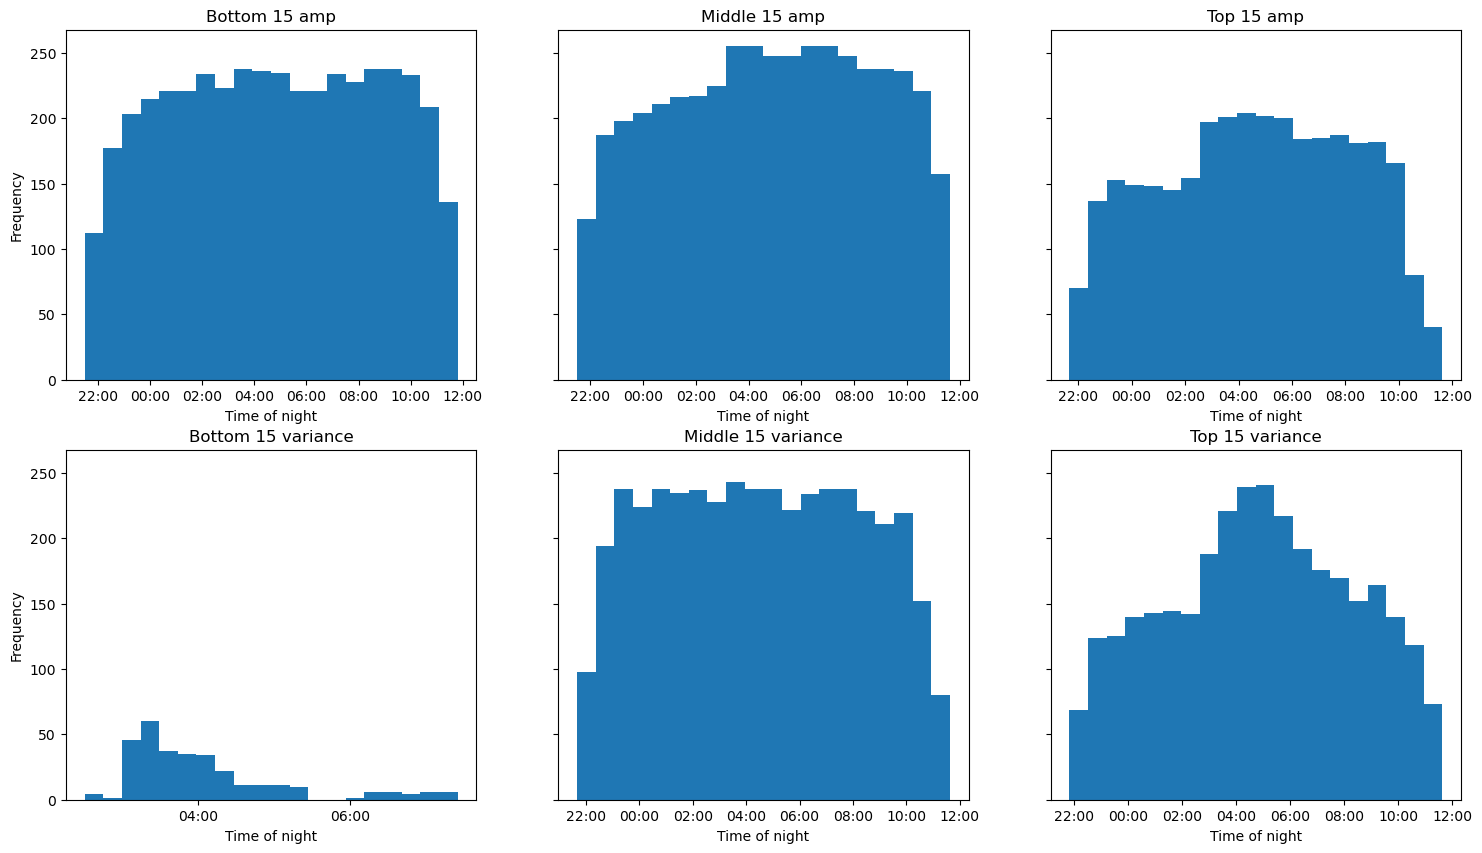

In [88]:
fig, ax = plt.subplots(2,3, sharey=True, figsize=(18,10))
# Format x-axis to display clock time (handles 24+ hours)
def fmt_time(x, pos):
    total_hours = x / 3600
    h = int(total_hours % 24)  # Wrap hours back to 0-23
    m = int((x % 3600) // 60)
    return f"{h:02d}:{m:02d}"

ax[0][0].hist(bottom15_data['time_of_night_shifted'], bins=20)
ax[0][0].set_ylabel("Frequency")
ax[0][0].set_xlabel("Time of night")
ax[0][0].set_title("Bottom 15 amp")

ax[0][1].hist(median15_data['time_of_night_shifted'], bins=20)
ax[0][1].set_xlabel("Time of night")
ax[0][1].set_title("Middle 15 amp")

ax[0][2].hist(top15_data['time_of_night_shifted'], bins=20)
ax[0][2].set_xlabel("Time of night")
ax[0][2].set_title("Top 15 amp")

ax[1][0].hist(bottom15var_data['time_of_night_shifted'], bins=20)
ax[1][0].set_ylabel("Frequency")
ax[1][0].set_xlabel("Time of night")
ax[1][0].set_title("Bottom 15 variance")

ax[1][1].hist(median15var_data['time_of_night_shifted'], bins=20)
ax[1][1].set_xlabel("Time of night")
ax[1][1].set_title("Middle 15 variance")

ax[1][2].hist(top15var_data['time_of_night_shifted'], bins=20)
ax[1][2].set_xlabel("Time of night")
ax[1][2].set_title("Top 15 variance")

# Apply formatting to all three axes
for a in ax[0]:
    a.xaxis.set_major_locator(MultipleLocator(2*3600))
    a.xaxis.set_major_formatter(FuncFormatter(fmt_time))
for a in ax[1]:
    a.xaxis.set_major_locator(MultipleLocator(2*3600))
    a.xaxis.set_major_formatter(FuncFormatter(fmt_time))

Text(0, 0.5, '2f amp variance')

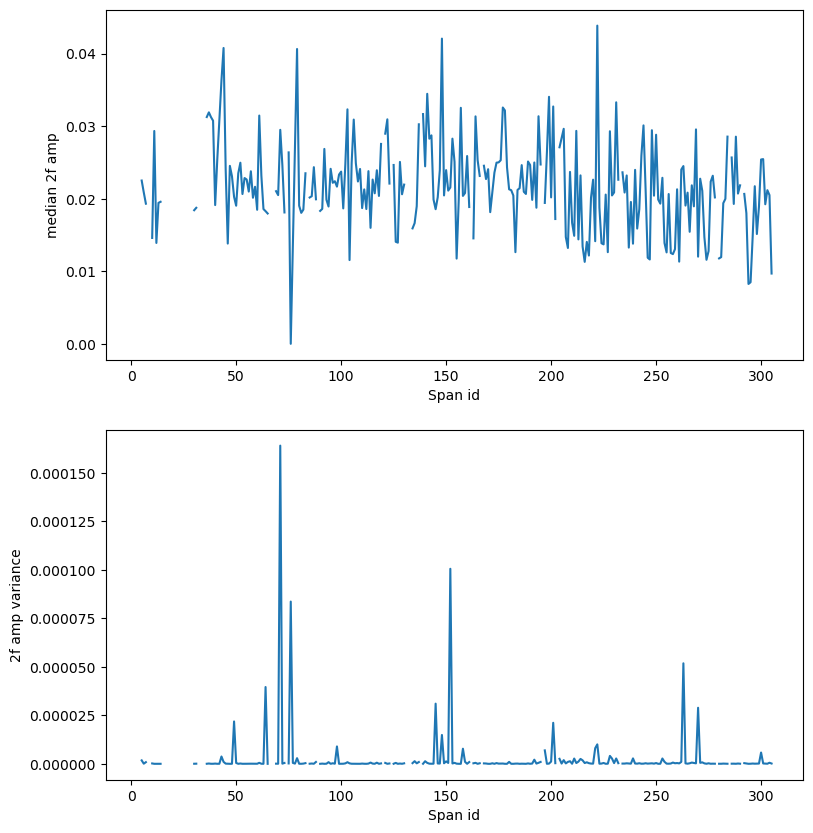

In [91]:
fig, ax = plt.subplots(2,1, figsize=(9,10))
ax[0].plot(pmed[393])
ax[0].set_xlabel("Span id")
ax[0].set_ylabel("median 2f amp")

ax[1].plot(pvar[393])
ax[1].set_xlabel("Span id")
ax[1].set_ylabel("2f amp variance")